# 1. 양자화란?

딥러닝에서 양자화(Quantization)는 원래 `float32, float16, bfloat16`처럼 연속적인 실수 값으로 표현되던 파라미터나 연산값을 더 적은 비트 수의 표현으로 바꾸는 방법

- 모델 크기 감소
- 메모리 사용량 감소
- 추론 속도 향상
- 전력 소모 감소
- 엣지 디바이스, 모바일, 임베디드 환경 배포 용이

**양자화는 모델을 더 가볍고 빠르게 만드는 기술**

# 2. 왜 양자화가 필요한가?

딥러닝 모델은 보통 매우 많은 수의 파라미터를 가지고 있음. 큰 언어 모델등은 수억 개에서 수십억 개의 weight를 가짐

- 저장 공간이 큼
- GPU/CPU 메모리를 많이 씀.
- 연산량이 큼
- 실제 서비스 환경에 올리기가 어려움.

예를 들어 float32는 하나의 값에 32비트가 필요.

그런데 이를 int8로 바꾸면 하나의 값에 8비트만 필요하므로, 단순 계산으로 4배 더 적은 메모리를 사용합니다.

# 3. 양자화의 기본 아이디어

> 연속적인 실수 범위를, 제한된 개수의 정수 또는 저장밀 표현으로 대응시키는 것


예를 들어, 실수값이 다음 범위에 있다고 하자.

$$
x \in [-1.0,1.0]
$$

이 값을 `int8` 범위인 `[-128, 127]`에 대응시키면, 실수값을 정수값으로 근사 할 수 있음.

보통 다음과 같은 형태를 사용

$$
x\approx s(q-z)
$$

또는

$$
q = round({\frac {x}{s}}) +z
$$
- $x$: 원래 실수값
- $q$: 양자화된 정수값
- $s$: scale
- $z$: zero-point

**실수<->정수** 사이를 변환하기 위해 scale과 zero-point로 둠.

- zero-point: 실수값 0을 정수 양자화 값의 어느 위치에 대응시킬지 정하는 오프셋
    - 실수 0이 정수 몇 번에 해당하는지?
    - 원점의 위치

# 4.양자화의 분류

## 4.1 비트 수의 기준 분류

### (1) INT8 양자화
- 8비트 정수 사용
- 정확도 손실이 비교적 작음
- 하드웨어 지원이 많음
- 실무 배포에서 가장 흔함

장점:

- 안정적
- 속도 향상 기대 가능
- 프렘임워크 지원이 풍부함

단점:

- INT4보다 압축률이 낮음

### (2) INT4 양자화

최근 LLM에서 많이 쓰임
- 4비트 정수 사용
- 메모리 절감 효과가 큼
- 대형 모델을 단일 장비에 올리기 쉬움

장점:

- 매우 큰 메모리 절감
- LLM 추론에 유리

단점:

- 정확도 손실 가능성 증가
- 하드웨어 지원이 제한적일 수 있음
- calibration이나 group-wise 전략이 더 중요해짐

### (3) INT2 / 1-bit / Binary / Ternary

아주 극단적인 저비트 양자화

- INT2: 2비트
- Binary: 1비트
- Ternary: -1, 0, 1 세값만 사용

장점:

- 압축률이 매우 큼
- 특정 특수 하드웨어에서 빠를 수 있음

단점:
- 정확도 손실이 큼
- 일반적인 범용 모델에는 적용이 쉽지 않음
- 연구적 성격이 강함

### (4) FP8

최근 고성능 학습/추론에서 주목받는 형식

- 정수 양자화는 다르게 부동소수점 표현을 유지
- FP16보다 더 낮은 정밀도
- 학습과 추론 모두에서 활용 가능

장점:

- 동적 범위 표현에 유리
- 일부 하드웨어에서 효율적

단점:

- 지원 하드웨어가 중요
- INT8처럼 단순하지 않음

### (5) NF4

LLM 양자화에 자주 언급되는 특수 형식

- NormalFloat4
- 보통 가중치 분포가 정규분포에 가깝다는 점을 활용
- QLoRA에서 많이 알려짐

장점:

- 일반 INT4보다 분포에 더 잘 맞는 경우가 있음
- LLM fine-tuning에 적함

단점:

- 범용 정수 양자화보다 개념이 조금 더 복잡함

## 4-2 대상 기준 분류

### (1) Weight Quantiozation

가중치만 양자화하는 방법

- 가장 기본적
- 구현이 비교적 쉬움
- 추론 배포에서 많이 사용

ex)

- FP16 activation + INT8 weights
- FP16 activation + INT4 weights

장점:

- 정확도 손실이 비교적 적음
- 적용이 쉬움

단점:

- activation까지 양자화하는 경우보다 속도/메모리 이득이 작을 수 있음

### (2) Activation Quantization

중간 활성화 값(activation)도 양자화

장점:

- 연산 전체를 저정밀도로 처리할 수 있어 실제 가속 효과가 커짐

단점:

- activation은 입력마다 값 범위가 달라져 더 어려움
- calibration이 매우 중요
- 정확도 저하 위험이 더 큼

### (3) Weight + Activation Quantization

가중치와 활성화 값을 모두 양자화하는 방식

장점:

- 메모리와 속도 측면에서 가장 큰 이득 가능

단점:

- 정확도 유지가 더 어려움
- Calibration, clipping, scale 설정이 중요

### (4) Gradient Quantization

학습 중 gradient를 낮은 정밀도로 표현하는 방법

장점:

- 분산 학습에서 통신 비용 감소
- 학습 메모리 감소 가능

단점:

- 학습 안정성 문제
- 구현 난이도 높음

주로 대규모 학습, 분산 학습 문맥에서 다뤄짐.


## 4-3. 스케일 적용 방식 기준
### (1) per-Tensor Quantization

하나의 텐서 자체에 대해 하나의 scale을 사용함.

- 예) 한 layer의 전체 weight tensor에 단일 scale 적용

장점:

- 단순함
- 구현이 쉬움
- 계산 오버헤드가 적음

단점:

- 텐서 내부 값 분포가 균일하지 않으면 오차가 커짐

### (2) Per-channel Quantization

채널별로 다른 scale을 사용

예:

- conv layer의 output channel마다 scale 다르게 적용
- Linear layer의 row 또는 column 단위로 적용

장점:

- 정확도 유지에 유리
- 분포 차이를 더 잘 반영함

단점

- 구현이 더 복잡함
- 메타데이터가 조금 더 필요함

**실무에서는 Per-channel weight Quantization**이 매우 자주 사용됨.

### (3) Group-wise Quantization

일정 개수의 weight를 그룹으로 묶고 그룹마다 scale을 둠.

예:

- 128개 weight마다 하나의 scale
- 64개 weight마다 하나의 scale


장점:

- per-tensor보다 정밀함
- per-channel보다 저장/계산 부담을 조절 가능
- LLM INT4 양자화에서 많이 사용

단점:

- 그룹 크기 선택이 성능에 영향을 줌

## 4-4 수식 형태 기준

### (1) Symmetric Quantization

대칭 양자화

범위를 보통 다음처럼 둠

$$
[-Q_{max}, Q_{max}]
$$

zero-point를 0으로 두는 경우가 많음

$$
q = round({\frac{x}{s}})
$$

장점:

- 구현이 단순함
- 연산이 간단함
- weight 양자화에 자주 사용

단점:

- 데이터 분포가 비대칭이면 비효율적일 수 있음.
### (2) Asymmetric Quantization

비대칭 양자화

실수값의 최소/최대 범위에 맞춰 zero-point을 둠

$$
q = round({\frac{x}{s}}) + z
$$

장점:

- 값 분포가 한쪽으로 치우친 경우 유리
- activation 양자화에서 많이 사용

단점:
- 연산이 조금 더 복잡함

In [ ]:
# 반올림만으로도 정보가 줄어듬

values = [0.1234, -0.8371, 1.4722, -2.3145, 0.0049]

rounded = []
for x in values:
    rounded.append(round(x, 1))

print("원래 값:", values)
print("반올림 :", rounded)

원래 값: [0.1234, -0.8371, 1.4722, -2.3145, 0.0049]
반올림 : [0.1, -0.8, 1.5, -2.3, 0.0]


- 값이 완전히 같지 않음
- 표현이 거칠어짐
- 작은 값은 0으로 사라질 수도 있음

**정밀도를 낮추면 정보가 줄어든다는 것**

In [ ]:
# 메모리 차이 보기

import numpy as np

arr_fp32 = np.array([0.12, -0.83, 1.47, -2.31, 0.004], dtype=np.float32)
arr_int8 = np.array([1, -8, 15, -23, 0], dtype=np.int8)

print("float32 배열:", arr_fp32)
print("int8 배열   :", arr_int8)

print("float32 dtype:", arr_fp32.dtype)
print("int8 dtype   :", arr_int8.dtype)

print("float32 전체 바이트:", arr_fp32.nbytes)
print("int8 전체 바이트   :", arr_int8.nbytes)

float32 배열: [ 0.12  -0.83   1.47  -2.31   0.004]
int8 배열   : [  1  -8  15 -23   0]
float32 dtype: float32
int8 dtype   : int8
float32 전체 바이트: 20
int8 전체 바이트   : 5


- float32는 원소 하나당 4바이트
- int8는 원소 하나당 1바이트

같은 개수의 값이라면:

- float32: 4배 더 큼
- int8: 4배 더 작음

**양자화를 하는 가장 큰 이유 중 하나**

In [ ]:
# 직접 양자화 하기

import numpy as np

x = np.array([0.12, -0.83, 1.47, -2.31, 0.04], dtype=np.float32)
print("원래 값:", x)

원래 값: [ 0.12 -0.83  1.47 -2.31  0.04]


- 왜 scale이 필요한가?
    - int8의 범위는 보통 다음입니다.
    - `-128 ~ 127`

실수 범위를 정수 범위에 맞춰 늘이거나 줄이는 비율이 필요 -> scale


단순하게는

` scale = max(abs) / 127`

In [ ]:
import numpy as np

x = np.array([0.12, -0.83, 1.47, -2.31, 0.04], dtype=np.float32)

scale = np.max(np.abs(x)) / 127
q = np.round(x / scale).astype(np.int8)

print("원래 값 x:")
print(x)

print("\nscale:")
print(scale)

print("\n양자화된 값 q:")
print(q)

원래 값 x:
[ 0.12 -0.83  1.47 -2.31  0.04]

scale:
0.018188976

양자화된 값 q:
[   7  -46   81 -127    2]


- 복원하기


$$
\hat{x} = q \cdot s
$$

In [ ]:
x_hat = q.astype(np.float32) * scale

print("복원된 값 x_hat:")
print(x_hat)

복원된 값 x_hat:
[ 0.12732282 -0.83669287  1.473307   -2.31        0.03637795]


In [ ]:
# 오차 계산하기
error = x - x_hat
abs_error = np.abs(error)

print("오차:")
print(error)

print("\n절대 오차:")
print(abs_error)

print("\n평균 절대 오차(MAE):"
print(np.mean(abs_error))

오차:
[-0.00732283  0.00669289 -0.00330698  0.          0.00362205]

절대 오차:
[0.00732283 0.00669289 0.00330698 0.         0.00362205]

평균 절대 오차(MAE):
0.004188949


- 오차가 0이면 완벽 복원
- 오차가 크면 양자화 손실이 큼
- 이 오차가 모델 정확도 저하로 이어질 수 있음

양자화에서는 항상 이 균형을 봐야 합니다.

> 얼마나 작아졌는가?

> 그 대신 얼마나 정보가 깨졌는가?

In [ ]:
# Scale
real_min = 0.0
real_max = 2.55
qmin = 0
qmax = 255

scale = (real_max - real_min) / (qmax - qmin)
print("scale =", scale)

scale = 0.009999999999999998


- 정수값이 1증가할 때, 실수값은 0.01씩 증가하는 구조

#### Zero-point

- 실수 값 0이 정수값에서 어디에 위치할지를 정하는 값

$$
q = round({\frac{x}{s}}) + z
$$

복원:
$$
\hat{x} = s(q-z)
$$

- $x$: 원래 실수
- $q$: 양자화된 정수
- $s$: scale
- $z$: zero-point


**왜 필요한가?**

실수 분포가 0을 중심으로 대칭이면 zero-point=0으로 해도 괜찮음.

하지만 데이터가 한쪽으로 치우쳐 있으면, zero-point를 적절히 두는 것이 훨씬 효율적


#### symmetric Quantization

 symeetric qunantization은 이름 그대로 0을 기준으로 대칭적인 범위를 쓰는 방식


 예를 들면, int8이면 보통 다음처럼 생각하자.
 $$
 [-127, 127]
 $$

 scale은 보통
 $$
 s = {\frac {max(|x|)}{127}}
 $$

 이 경우 zero-point는 보통 0
 $$
 z=0
 $$

 양자화식은 단순해짐
 $$
 q = round({\frac{x}{s}})
 $$

 복원:
 $$
 \hat{x} = sq
 $$

 장점:
 - 구현이 단순함
 - 연산이 간단함
 - 하드웨어 친화적
 - weight quantization에 자주 사용됨
  
단점:
- 데이터가 비대칭이면 표현 범위를 낭비할 수 있음
- activation처럼 양수 쪽에 몰린 데이터는 비효율적일 수 있음

In [ ]:
# Symmetric quantization
import numpy as np

x = np.array([-2.3, -1.0, 0.0, 1.2, 2.0], dtype=np.float32)

scale = np.max(np.abs(x)) / 127
q = np.round(x / scale).astype(np.int8)
x_hat = q.astype(np.float32) * scale

print("원래 값 x:", x)
print("scale:", scale)
print("양자화 q:", q)
print("복원 x_hat:", x_hat)
print("절대 오차:", np.abs(x - x_hat))

원래 값 x: [-2.3 -1.   0.   1.2  2. ]
scale: 0.018110236
양자화 q: [-127  -55    0   66  110]
복원 x_hat: [-2.3       -0.996063   0.         1.1952755  1.992126 ]
절대 오차: [0.         0.00393701 0.         0.0047245  0.00787401]


#### asymmetric quantization

실수의 최소값과 최대값을 정수 범위 전체에 더 촘촘히 대응시키는 방식


예를 들어, `unit8` 범위를 사용한다고 하자.

$$
q \in [0,255]
$$

실수 범위가
$$
[x_{min}, x_{max}]
$$

일 때,

$$
s = {\frac {x_{min} - x_{max}} {q_{max} - q_{min}}}
$$

zero-point는 보통 다음처럼 잡음.
$$
z = round(q_{min} - {\frac {x_{min}}{s}})
$$


양자화
$$
 q = round({\frac{x}{s}}) + z
 $$

 복원:
 $$
 \hat{x} = s(q-z)
 $$


 실제로는 `qmin ~ qmax` 범위로 clamp도 함.


장점
- 비대칭 분포에 잘 맞음
- activation처럼 양수 편향 데이터에 유리
- 정수 표현 범위를 더 효율적으로 사용 가능


단점
- zero-point 때문에 계산이 조금 더 복잡함
- 일부 하드웨어에서는 symmetric보다 덜 단순함


In [ ]:
# asymmetric quantization
import numpy as np

x = np.array([0.2, 0.5, 1.0, 1.8, 2.3], dtype=np.float32)

qmin = 0
qmax = 255

x_min = np.min(x)
x_max = np.max(x)

scale = (x_max - x_min) / (qmax - qmin)
zero_point = np.round(qmin - x_min / scale).astype(np.int32)

q = np.round(x / scale + zero_point)
q = np.clip(q, qmin, qmax).astype(np.uint8)

x_hat = (q.astype(np.float32) - zero_point) * scale

print("원래 값 x:", x)
print("x_min:", x_min)
print("x_max:", x_max)
print("scale:", scale)
print("zero_point:", zero_point)
print("양자화 q:", q)
print("복원 x_hat:", x_hat)
print("절대 오차:", np.abs(x - x_hat))

In [ ]:
# symmetric와 asymmetric를 같은 데이터에 비교

import numpy as np

x = np.array([0.2, 0.5, 1.0, 1.8, 2.3], dtype=np.float32)

# ---------------------------
# 1) symmetric quantization
# ---------------------------
scale_sym = np.max(np.abs(x)) / 127
q_sym = np.round(x / scale_sym).astype(np.int8)
x_hat_sym = q_sym.astype(np.float32) * scale_sym
mae_sym = np.mean(np.abs(x - x_hat_sym))

# ---------------------------
# 2) asymmetric quantization
# ---------------------------
qmin = 0
qmax = 255
x_min = np.min(x)
x_max = np.max(x)

scale_asym = (x_max - x_min) / (qmax - qmin)
zero_point = np.round(qmin - x_min / scale_asym).astype(np.int32)

q_asym = np.round(x / scale_asym + zero_point)
q_asym = np.clip(q_asym, qmin, qmax).astype(np.uint8)
x_hat_asym = (q_asym.astype(np.float32) - zero_point) * scale_asym
mae_asym = np.mean(np.abs(x - x_hat_asym))

print("원래 x:", x)

print("\n[Symmetric]")
print("scale:", scale_sym)
print("q:", q_sym)
print("x_hat:", x_hat_sym)
print("MAE:", mae_sym)

print("\n[Asymmetric]")
print("scale:", scale_asym)
print("zero_point:", zero_point)
print("q:", q_asym)
print("x_hat:", x_hat_asym)
print("MAE:", mae_asym)

- per-tensor quantization: 텐서 전체에 하나의 scale을 적용하는 방식. 구현이 가장 단순하지만, 텐서 안의 값 범위 차이가 크면 오차가 커질 수 있음

In [ ]:
# 공통 양자화 함수
import torch

def quantize_symmetric(tensor, scale, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1
    q = torch.round(tensor / scale)
    q = torch.clamp(q, -qmax, qmax)
    return q

def dequantize(q, scale):
    return q * scale

In [ ]:
# 실습용 weight 만들기
torch.manual_seed(0)

W = torch.tensor([
    [0.1, 0.2, 0.15, 0.18],
    [10.0, 9.5, 11.0, 10.5],
    [0.01, 0.02, 0.015, 0.018],
    [3.0, 2.5, 3.2, 2.8]
], dtype=torch.float32)

print(W)

tensor([[1.0000e-01, 2.0000e-01, 1.5000e-01, 1.8000e-01],
        [1.0000e+01, 9.5000e+00, 1.1000e+01, 1.0500e+01],
        [1.0000e-02, 2.0000e-02, 1.5000e-02, 1.8000e-02],
        [3.0000e+00, 2.5000e+00, 3.2000e+00, 2.8000e+00]])


In [ ]:
# per-Tensor Quantization
## 전체 텐서에 scale 하나를 씀
def per_tensor_quantize(W, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1
    scale = W.abs().max() / qmax

    q = quantize_symmetric(W, scale, num_bits)
    W_hat = dequantize(q, scale)

    return q, W_hat, scale

In [ ]:
q_tensor, W_tensor_hat, scale_tensor = per_tensor_quantize(W)

print("Per-Tensor scale:", scale_tensor.item())
print("복원 weight:\n", W_tensor_hat)

Per-Tensor scale: 0.08661417663097382
복원 weight:
 tensor([[ 0.0866,  0.1732,  0.1732,  0.1732],
        [ 9.9606,  9.5276, 11.0000, 10.4803],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 3.0315,  2.5118,  3.2047,  2.7717]])


In [ ]:
# 오차 확인
tensor_error = torch.mean((W - W_tensor_hat) ** 2)
print("Per-Tensor MSE:", tensor_error.item())

Per-Tensor MSE: 0.00044903947855345905


- per-channel quantization: 채널마다 서로 다른 scale을 적용하는 방식.
    - 채널별 분포 차이를 잘 반영해서 정확도 유지에 더 유리

In [ ]:
#per-channel Quantization
## row별 scale을 사용함.

def per_channel_quantize(W, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1

    scales = W.abs().max(dim=1, keepdim=True).values / qmax
    q = quantize_symmetric(W, scales, num_bits)
    W_hat = dequantize(q, scales)

    return q, W_hat, scales

In [ ]:
q_channel, W_channel_hat, scales_channel = per_channel_quantize(W)

print("Per-Channel scales:\n", scales_channel)
print("복원 weight:\n", W_channel_hat)

Per-Channel scales:
 tensor([[0.0016],
        [0.0866],
        [0.0002],
        [0.0252]])
복원 weight:
 tensor([[1.0079e-01, 2.0000e-01, 1.4961e-01, 1.7953e-01],
        [9.9606e+00, 9.5276e+00, 1.1000e+01, 1.0480e+01],
        [9.9213e-03, 2.0000e-02, 1.4961e-02, 1.7953e-02],
        [2.9984e+00, 2.4945e+00, 3.2000e+00, 2.7969e+00]])


In [ ]:
#오차 비교
channel_error = torch.mean((W - W_channel_hat) ** 2)

print("Per-Tensor MSE :", tensor_error.item())
print("Per-Channel MSE:", channel_error.item())

Per-Tensor MSE : 0.00044903947855345905
Per-Channel MSE: 0.00017129724437836558


- Group-wise Quantization: 일정 개수의 값들을 그룹으로 묶고 그룹마다 scale을 적용하는 방식
    - per-tensor보다 정밀하고, per-channel보다 저장, 계산 부담을 조절하기 좋음

In [ ]:
def groupwise_quantize(W, group_size=2, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1
    W_hat = torch.zeros_like(W)
    scales = []

    for i in range(W.shape[0]):
        for j in range(0, W.shape[1], group_size):
            group = W[i, j:j+group_size]
            scale = group.abs().max() / qmax

            q = quantize_symmetric(group, scale, num_bits)
            group_hat = dequantize(q, scale)

            W_hat[i, j:j+group_size] = group_hat
            scales.append(scale.item())

    return W_hat, scales

In [ ]:
W_group_hat, group_scales = groupwise_quantize(W, group_size=2)

group_error = torch.mean((W - W_group_hat) ** 2)

print("Group scales:", group_scales)
print("복원 weight:\n", W_group_hat)
print("Group-wise MSE:", group_error.item())

Group scales: [0.0015748031437397003, 0.0014173228992149234, 0.07874015718698502, 0.08661417663097382, 0.00015748031728435308, 0.00014173227827996016, 0.023622047156095505, 0.025196850299835205]
복원 weight:
 tensor([[1.0079e-01, 2.0000e-01, 1.5024e-01, 1.8000e-01],
        [1.0000e+01, 9.5276e+00, 1.1000e+01, 1.0480e+01],
        [9.9213e-03, 2.0000e-02, 1.5024e-02, 1.8000e-02],
        [3.0000e+00, 2.5039e+00, 3.2000e+00, 2.7969e+00]])
Group-wise MSE: 7.331918459385633e-05


# 5. 양자화 방법의 대표 분류

## (1) Post-Training Quantization, PTQ

**PTQ(Post-Training Quantization)** 는  
**학습이 끝난 뒤** 모델을 양자화하는 방법.

먼저 일반적인 부동소수점 모델을 충분히 학습한 다음,  그 학습된 모델의 **weight** 와 필요하면 **activation** 을   INT8, INT4 같은 저정밀 표현으로 변환.

---

### 기본 흐름

1. 먼저 float 모델을 학습하고
2. 학습 완료 후
3. weight나 activation을 저정밀도로 변환합니다

PTQ는 **학습 단계와 양자화 단계를 분리**하는 방식.

---

### 수식적 관점

양자화의 기본적인 선형 표현은 다음과 같음.

$$
q = \operatorname{round}\left(\frac{x}{s}\right) + z
$$

$$
\hat{x} = s(q - z)
$$

여기서

- $x$: 원래의 실수값
- $q$: 양자화된 정수값
- $s$: scale
- $z$: zero-point
- $\hat{x}$: 복원된 근사값


PTQ는 학습이 끝난 뒤 이미 학습된 실수값 $x$ 를 정수값 $q$ 로 바꾸고, 추론 시에는 다시 $\hat{x}$ 로 복원하여 사용하는 방식.

---

### 특징

- 추가 학습이 거의 없거나 전혀 없음
- 빠르고 간단함
- 배포 직전에 적용하기 좋음

PTQ는 **기존 모델을 빠르게 경량화**하고 싶을 때 매우 실용적.

---

### 장점

- 구현이 쉬움
- 기존 모델을 바로 줄일 수 있음
- 비용이 적음

특히 이미 잘 학습된 모델이 있고, 그 모델을 다시 학습시키기 어렵거나 시간이 부족할 때 유용.

---

### 단점

- 정확도 손실이 있을 수 있음
- 특히 activation 양자화 시 calibration이 중요함

가중치만 양자화할 때보다 **activation까지 양자화할 때 정확도 저하 위험이 더 커질 수 있습니다.**

그 이유는 activation 값의 범위가 입력 데이터에 따라 달라질 수 있기 때문.

---

## PTQ의 세부 형태

PTQ는 activation 범위를 **언제, 어떻게 정하느냐**에 따라 주로 **Dynamic Quantization** 과 **Static Quantization** 으로 나뉨.

---

## 1) Dynamic Quantization

**Dynamic Quantization** 은  
실행 중 activation 범위를 **동적으로 계산**하는 방식.



- weight는 미리 양자화하고
- activation은 추론 시점에 scale을 결정

---

### 동작 방식

모델의 weight는 미리 정수형으로 양자화해 둠.  
반면 activation은 입력이 실제로 들어왔을 때 그 값의 범위를 보고 그때그때 적절한 scale을 계산.

예를 들어 activation $a$ 에 대해 추론 시점에

$$
s_a = \frac{\max(|a|)}{q_{\max}}
$$

와 같이 scale을 정한 뒤 양자화를 수행할 수 있다.

activation 범위를 **미리 고정하지 않고**  
입력에 따라 유연하게 처리하는 방식.

---

### 장점

- 적용이 쉬움
- Transformer, LSTM, Linear layer 등에 간단히 적용 가능

특히 NLP 계열 모델이나 Linear 연산 중심의 구조에서는 빠르게 적용하기 좋음.

---

### 단점

- 정적 방식보다 최적화가 덜 될 수 있음

실행 시마다 activation 범위를 계산해야 하므로  정적 양자화에 비해 하드웨어 최적화나 배포 효율이 다소 떨어질 수 있음.

---

## 2) Static Quantization

**Static Quantization** 은 weight와 activation 모두의 범위를 **미리 정해 두는 방식**.

실제 배포 전에 calibration dataset을 사용해서 activation의 통계를 수집하고, 그 통계를 바탕으로 scale과 zero-point를 고정.

---

### 기본 과정

1. calibration dataset 준비
2. activation 통계 수집
3. scale / zero-point 결정
4. 정적 양자화 모델 생성

---

### 수식적 관점

calibration 데이터에서 activation 범위를

$$
[a_{\min}^{\mathrm{cal}}, a_{\max}^{\mathrm{cal}}]
$$

라고 추정하면, asymmetric quantization에서는

예를 들어

$$
s = \frac{a_{\max}^{\mathrm{cal}} - a_{\min}^{\mathrm{cal}}}{q_{\max} - q_{\min}}
$$

$$
z = \operatorname{round}\left(q_{\min} - \frac{a_{\min}^{\mathrm{cal}}}{s}\right)
$$

로 정할 수 있음.

그 다음 실제 추론에서는 이렇게 미리 정한 $s$ 와 $z$ 를 계속 사용.

실행 중 매번 범위를 다시 구하지 않고 **사전에 고정된 양자화 규칙**으로 동작.

---

### 장점

- 더 높은 성능과 가속 가능
- 배포 효율적

Dynamic Quantization보다 실제 배포 환경에서 더 효율적으로 최적화될 가능성이 높음.

---

### 단점

- calibration 과정 필요
- 데이터 대표성이 중요

만약 calibration dataset이 실제 입력 분포를 잘 대표하지 못하면, scale이 부적절하게 정해져 정확도 저하가 발생할 수 있다.

예를 들어 activation 범위를 너무 넓게 잡으면  
작은 값 표현이 거칠어지고,  
너무 좁게 잡으면 clipping이 많이 발생할 수 있다.

---

## Dynamic Quantization vs Static Quantization

| 구분 | Dynamic Quantization | Static Quantization |
|---|---|---|
| weight | 미리 양자화 | 미리 양자화 |
| activation 범위 | 추론 시 동적으로 계산 | calibration으로 미리 고정 |
| 적용 난이도 | 더 쉬움 | 더 복잡함 |
| 배포 최적화 | 상대적으로 제한적 | 더 유리함 |
| 대표 사용처 | Transformer, LSTM, Linear 중심 | CNN, CV 모델, 엣지 배포 등 |

---

## PTQ에서 calibration이 중요한 이유

특히 Static Quantization에서는 activation의 범위를 적절히 추정하는 것이 매우 중요.

보통 calibration 과정에서는 다음과 같은 통계를 수집.

- 최소값(min)
- 최대값(max)
- percentile
- histogram

이 정보를 바탕으로 너무 넓지도, 너무 좁지도 않은 범위를 정해야 합니다.

### 범위를 너무 넓게 잡으면
- 정수 표현의 해상도가 낮아져 정밀도가 떨어짐

### 범위를 너무 좁게 잡으면
- clipping이 많아져 큰 값 정보가 손실됨

PTQ의 성능은 단순히 비트를 줄이는 것만이 아니라 **적절한 범위 설정**에 크게 좌우됨.

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(0)

# 간단한 Linear layer
linear = nn.Linear(4, 2)

# 입력
x = torch.randn(3, 4)

print("입력 x:\n", x)
print("원래 출력:\n", linear(x))

입력 x:
 tensor([[ 0.1604, -0.6065, -0.7831,  1.0622],
        [-0.2613,  1.0667,  0.4159,  0.8396],
        [-0.8265, -0.7949, -0.9528,  0.3717]])
원래 출력:
 tensor([[-0.2762,  0.4490],
        [-0.2374,  0.6544],
        [ 0.0008,  0.3417]], grad_fn=<AddmmBackward0>)


In [ ]:
# 공통 양자화 함수
## symmetric quantization

def symmetric_quantize(x, scale, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1
    q = torch.round(x / scale)
    q = torch.clamp(q, -qmax, qmax)
    return q

def dequantize(q, scale):
    return q * scale

In [ ]:
# Dynamic Quantization 실습
## weight는 미리 양자화
## activation은 입력마다 scale 다시 계산
def dynamic_quant_linear(linear, x, num_bits=8):
    # weight 미리 양자화
    w = linear.weight.data
    w_scale = w.abs().max() / (2 ** (num_bits - 1) - 1)

    q_w = symmetric_quantize(w, w_scale, num_bits)
    w_hat = dequantize(q_w, w_scale)

    # activation scale을 입력마다 동적 계산
    x_scale = x.abs().max() / (2 ** (num_bits - 1) - 1)

    q_x = symmetric_quantize(x, x_scale, num_bits)
    x_hat = dequantize(q_x, x_scale)

    y = x_hat @ w_hat.t() + linear.bias
    return y, x_scale, w_scale


In [ ]:
y_dynamic, x_scale_dynamic, w_scale_dynamic = dynamic_quant_linear(linear, x)

print("Dynamic activation scale:", x_scale_dynamic.item())
print("Dynamic output:\n", y_dynamic)

Dynamic activation scale: 0.00839921087026596
Dynamic output:
 tensor([[-0.2770,  0.4474],
        [-0.2397,  0.6518],
        [-0.0022,  0.3390]], grad_fn=<AddBackward0>)


In [ ]:
# Static Quantization 실습
## activation scale을 미리 calibration dataset으로 고정
### 데이터 준비
calib_data = torch.randn(100, 4)

In [ ]:
#calibration으로 activation 범위 고정
def calibrate_scale(data, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1
    scale = data.abs().max() / qmax
    return scale

In [ ]:
x_scale_static = calibrate_scale(calib_data)
print("Static calibration scale:", x_scale_static.item())

Static calibration scale: 0.02685435116291046


In [ ]:
# Static Quantization 적용
def static_quant_linear(linear, x, x_scale, num_bits=8):
    # weight 미리 양자화
    w = linear.weight.data
    w_scale = w.abs().max() / (2 ** (num_bits - 1) - 1)

    q_w = symmetric_quantize(w, w_scale, num_bits)
    w_hat = dequantize(q_w, w_scale)

    # activation scale은 calibration 값 고정 사용
    q_x = symmetric_quantize(x, x_scale, num_bits)
    x_hat = dequantize(q_x, x_scale)

    y = x_hat @ w_hat.t() + linear.bias
    return y

In [ ]:
y_static = static_quant_linear(linear, x, x_scale_static)

print("Static output:\n", y_static)

Static output:
 tensor([[-0.2873,  0.4517],
        [-0.2279,  0.6515],
        [-0.0104,  0.3422]], grad_fn=<AddBackward0>)


In [ ]:
# 원래 float 모델과 비교
y_float = linear(x)

print("Float output:\n", y_float)
print("Dynamic output:\n", y_dynamic)
print("Static output:\n", y_static)

Float output:
 tensor([[-0.2762,  0.4490],
        [-0.2374,  0.6544],
        [ 0.0008,  0.3417]], grad_fn=<AddmmBackward0>)
Dynamic output:
 tensor([[-0.2770,  0.4474],
        [-0.2397,  0.6518],
        [-0.0022,  0.3390]], grad_fn=<AddBackward0>)
Static output:
 tensor([[-0.2873,  0.4517],
        [-0.2279,  0.6515],
        [-0.0104,  0.3422]], grad_fn=<AddBackward0>)


In [ ]:
# 오차 비교
dynamic_error = torch.mean((y_float - y_dynamic) ** 2)
static_error = torch.mean((y_float - y_static) ** 2)

print("Dynamic MSE:", dynamic_error.item())
print("Static MSE :", static_error.item())

Dynamic MSE: 5.3636958909919485e-06
Static MSE : 5.922031414229423e-05


In [ ]:
#입력 분포를 바꿔보기
##Dynamic과 Static의 차이를 더 명확히 보려면 입력 분포 바꿔봄
x2 = 5 * torch.randn(3, 4)

y_float2 = linear(x2)
y_dynamic2, _, _ = dynamic_quant_linear(linear, x2)
y_static2 = static_quant_linear(linear, x2, x_scale_static)

print("Dynamic new input MSE:",
      torch.mean((y_float2 - y_dynamic2) ** 2).item())

print("Static new input MSE:",
      torch.mean((y_float2 - y_static2) ** 2).item())

Dynamic new input MSE: 0.0005868664593435824
Static new input MSE: 1.981718897819519


## (2) Quantization-Aware Training, QAT

**QAT(Quantization-Aware Training)** 은 **학습 중 양자화를 고려하면서 훈련하는 방법**.

모델을 먼저 완전히 학습한 뒤 마지막에 양자화하는 것이 아니라, 학습 과정 자체에서 **양자화 오차를 반영**하여   모델이 저정밀 환경에 적응하도록 만드는 방식.

---

### 핵심 아이디어

- forward에서는 양자화된 것처럼 흉내냄
- backward에서는 gradient가 흐르도록 근사 사용

실제로는 보통 **fake quantization** 을 넣어서 학습.


QAT의 목표는 다음과 같습니다.

> 모델이 훈련 중에 양자화 오차를 미리 경험하게 해서,  
> 양자화 후 정확도 하락을 줄이려는 것

---

## 1. 기본 수식 아이디어

양자화의 기본 형태는 다음과 같습니다.

$$
q = \operatorname{round}\left(\frac{x}{s}\right) + z
$$

$$
\hat{x} = s(q - z)
$$

여기서

- $x$ : 원래의 실수값
- $q$ : 양자화된 정수값
- $s$ : scale
- $z$ : zero-point
- $\hat{x}$ : 양자화 후 다시 복원된 근사값

PTQ에서는 이 과정을 **학습 후** 적용하지만,QAT에서는 이 과정을 **학습 중 forward 안에 포함**시킴.

---

## 2. QAT의 forward 수식

QAT에서는 실제로 완전히 int 연산만 하는 것이 아니라, 보통 **양자화-복원 과정을 흉내 낸 값**을 forward에 넣습니다.

이를 fake quantization으로 표현하면,

$$
\tilde{x}
=
\operatorname{Dequantize}(\operatorname{Quantize}(x))
$$



$$
\tilde{x}
=
s\left(
\operatorname{clip}
\left(
\operatorname{round}\left(\frac{x}{s}\right) + z,\;
q_{\min}, q_{\max}
\right)
- z
\right)
$$


여기서 $\tilde{x}$ 는 실제 정수로 완전히 저장된 값이 아니라, **양자화된 것처럼 보이도록 만든 float 근사값**.

forward에서는 원래 $x$ 대신 $\tilde{x}$ 를 사용.

---

## 3. 선형층에서의 QAT 예시

원래 선형층이

$$
y = Wx + b
$$

라고 하면, QAT에서는 보통 weight와 activation 모두에 fake quantization을 적용하여

$$
\tilde{W} = Q_f(W), \qquad \tilde{x} = Q_f(x)
$$

$$
y = \tilde{W}\tilde{x} + \tilde{b}
$$

처럼 계산.

여기서 $Q_f(\cdot)$ 는 fake quantization 연산.

학습 중 모델은 실제로는 float로 계산되더라도 입력과 가중치가 이미 양자화된 것 같은 환경에서 forward를 수행하게 됨.

---

## 4. 왜 fake quantization이 필요한가?

문제는 양자화 연산 안에 다음과 같은 비미분 연산이 들어 있다는 점.

$$
\operatorname{round}(\cdot)
$$

또는 clipping 연산

$$
\operatorname{clip}(\cdot)
$$

이런 연산은 일반적인 의미에서 gradient를 계산하기 어려움.

만약 그대로 사용하면 backpropagation이 막히거나 매우 불안정해질 수 있음.

그래서 QAT에서는 forward에서는 실제 양자화 효과를 반영하되, backward에서는 gradient가 흐를 수 있도록 **근사 기법**을 사용.

---

## 5. Straight-Through Estimator, STE

QAT에서 가장 대표적인 gradient 근사는 **STE(Straight-Through Estimator)**.

직관적으로는 다음처럼 생각.

### forward
실제로는 양자화 연산 수행

$$
\tilde{x} = Q_f(x)
$$

### backward
미분은 양자화 연산을 무시하고 그대로 통과시키는 근사 사용

이상적으로는

$$
\frac{\partial \tilde{x}}{\partial x}
=
\frac{\partial Q_f(x)}{\partial x}
$$

를 계산해야 하지만, round는 미분이 거의 0이거나 정의가 애매하므로  실제로는 다음처럼 근사.

$$
\frac{\partial \tilde{x}}{\partial x} \approx 1
$$


$$
\frac{\partial \mathcal{L}}{\partial x}
\approx
\frac{\partial \mathcal{L}}{\partial \tilde{x}}
$$

로 둠.

이것이 STE의 핵심.

---

## 6. STE를 포함한 fake quantization의 해석

실제로 QAT에서는 forward에서

$$
x \rightarrow \tilde{x} = Q_f(x)
$$

를 사용하지만, backward에서는 마치

$$
\tilde{x} \approx x
$$

인 것처럼 gradient를 흘려보냄.


- 값은 양자화된 값으로 학습
- gradient는 원래 float 파라미터에 전달

하게 됨.

그래서 모델은 양자화 오차를 경험하면서도 학습 자체는 계속 진행할 수 있음.

---

## 7. QAT의 전체 학습 관점

원래의 학습 목표가

$$
\min_W \mathcal{L}(f(x; W), y)
$$

라고 하면, QAT에서는 실제로는 양자화된 근사 파라미터를 거친 모델을 최적화함.


$$
\min_W \mathcal{L}(f(Q_f(x); Q_f(W)), y)
$$

또는 activation을 명시적으로 쓰면

$$
\min_W \mathcal{L}(f(\tilde{x}; \tilde{W}), y)
$$

를 풀게 됨.

여기서 중요한 점은  
최적화 대상 자체는 여전히 float 파라미터 $W$ 이지만 forward는 $Q_f(W)$ 를 통해 이루어진다는 것.

QAT는 **float 파라미터를 학습하지만, 양자화된 모델의 성능을 직접 최적화하려는 방식**으로 볼 수 있음.

---

## 8. QAT의 장점

- PTQ보다 정확도 유지가 좋은 경우가 많음
- 저비트 양자화에서 특히 효과적

그 이유는 모델이 학습 중부터  
양자화 오차를 포함한 환경에 적응하기 때문.

특히 INT8보다 더 낮은 정밀도,  
예를 들어 INT4처럼 오차가 커질 수 있는 환경에서는  
QAT의 장점이 더 크게 나타날 수 있음.

---

## 9. QAT의 단점

- 재학습 비용이 큼
- 구현이 더 복잡함
- 학습 시간이 증가함

QAT는 정확도 유지에는 유리하지만 학습 비용과 엔지니어링 복잡성이 커짐.


- 아주 작은 회귀 문제를 사용
$$
y=2x+1
$$

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)

In [ ]:
# 데이터 준비
x = torch.linspace(-1, 1, 200).unsqueeze(1)
y = 2 * x + 1

print(x[:5])
print(y[:5])

tensor([[-1.0000],
        [-0.9899],
        [-0.9799],
        [-0.9698],
        [-0.9598]])
tensor([[-1.0000],
        [-0.9799],
        [-0.9598],
        [-0.9397],
        [-0.9196]])


In [ ]:
# 가장 기본 모델 정의
class SimpleLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [ ]:
# 공통 학습 함수
def train_model(model, x, y, epochs=300, lr=0.1):
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

In [ ]:
#float 모델 먼저 학습
float_model = SimpleLinear()
float_losses = train_model(float_model, x, y)

print("Float weight:", float_model.linear.weight.item())
print("Float bias  :", float_model.linear.bias.item())
print("Final float loss:", float_losses[-1])

Float weight: 1.9999991655349731
Float bias  : 0.9999998807907104
Final float loss: 2.5947245654162066e-13


In [ ]:
# float 모델 성능 확인
with torch.no_grad():
    y_float = float_model(x)
    float_mse = ((y - y_float) ** 2).mean().item()

print("Float model MSE:", float_mse)

Float model MSE: 2.5947245654162066e-13


In [ ]:
# 양자화 함수 만들기
## symmetric quantization 기준

def quantize_dequantize_symmetric(tensor, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1

    max_val = tensor.abs().max()
    if max_val == 0:
        return tensor.clone()

    scale = max_val / qmax
    q = torch.round(tensor / scale)
    q = torch.clamp(q, -qmax, qmax)
    dq = q * scale
    return dq

In [ ]:
# PTQ 실습
## 먼저 학습된 float 모델을 사후 양자화해보자.
with torch.no_grad():
    w = float_model.linear.weight.data.clone()
    b = float_model.linear.bias.data.clone()

    w_ptq = quantize_dequantize_symmetric(w, num_bits=4)
    b_ptq = quantize_dequantize_symmetric(b, num_bits=4)

    y_ptq = x @ w_ptq.t() + b_ptq
    ptq_mse = ((y - y_ptq) ** 2).mean().item()

print("PTQ weight:", w_ptq.item())
print("PTQ bias  :", b_ptq.item())
print("PTQ MSE   :", ptq_mse)

PTQ weight: 1.9999992847442627
PTQ bias  : 0.9999998211860657
PTQ MSE   : 2.0751400543663617e-13


- 모델은 float로 학습
- 학습 끝난 뒤
- weight, bias를 저정밀로 근사

**QAT 핵심:fake quanitzation**

QAT에서는 학습 중 forward 안에 양자화 흉내를 넣음.

하지만 문제가 있음.

- round()는 미분이 어렵습니다.
- 그대로 쓰면 학습이 잘 안 될 수 있습니다.

그래서 STE 느낌의 trick

In [ ]:
# STE기반 fake quantization 함수
def fake_quant_ste(tensor, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1

    max_val = tensor.abs().max().detach()
    # forward 값은 dq(양자화된 것처럼 동작)
    # backward gradient는 tensor 기준으로 흐름(Gradient 통과)
    if max_val == 0:
        return tensor

    scale = max_val / qmax
    q = torch.round(tensor / scale)
    q = torch.clamp(q, -qmax, qmax)
    dq = q * scale

    # forward는 dq 사용, backward는 tensor처럼 gradient 전달
    return tensor + (dq - tensor).detach()

In [ ]:
# QAT용 모델 정의
## 학습 중 weight와 bias를 fake quantization해서 쓰는 모델을 만듦.
class QATLinear(nn.Module):
    def __init__(self, num_bits=8):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        self.num_bits = num_bits

    def forward(self, x):
        q_weight = fake_quant_ste(self.linear.weight, self.num_bits)
        q_bias = fake_quant_ste(self.linear.bias, self.num_bits)
        return x @ q_weight.t() + q_bias

In [ ]:
# QAT 모델 학습
## 4-bit처럼 더 어려운 조건으로 해보자
qat_model = QATLinear(num_bits=4)
qat_losses = train_model(qat_model, x, y)

print("QAT-trained weight:", qat_model.linear.weight.item())
print("QAT-trained bias  :", qat_model.linear.bias.item())
print("Final QAT loss    :", qat_losses[-1])

QAT-trained weight: 1.9999991655349731
QAT-trained bias  : 0.9999999403953552
Final QAT loss    : 1.8044233099888396e-13


In [ ]:
# QAT 학습 후 최종 양자화
## QAT의 핵심은 학습 중 fake quantization으로 적응하고, 최종 배포 단계에서는 실제 양자화 모델을 만든다는 점with torch.no_grad():
with torch.no_grad():
    w_qat = qat_model.linear.weight.data.clone()
    b_qat = qat_model.linear.bias.data.clone()

    w_qat_final = quantize_dequantize_symmetric(w_qat, num_bits=4)
    b_qat_final = quantize_dequantize_symmetric(b_qat, num_bits=4)

    y_qat_final = x @ w_qat_final.t() + b_qat_final
    qat_final_mse = ((y - y_qat_final) ** 2).mean().item()

print("QAT final weight:", w_qat_final.item())
print("QAT final bias  :", b_qat_final.item())
print("QAT final MSE   :", qat_final_mse)

QAT final weight: 1.9999992847442627
QAT final bias  : 0.9999999403953552
QAT final MSE   : 1.8044233099888396e-13


In [ ]:
# 결과 비교
print("Float MSE :", float_mse)
print("PTQ MSE   :", ptq_mse)
print("QAT MSE   :", qat_final_mse)

Float MSE : 2.5947245654162066e-13
PTQ MSE   : 2.0751400543663617e-13
QAT MSE   : 1.8044233099888396e-13


# 7. Calibration이란?

**Calibration** 은 특히 **PTQ(Post-Training Quantization)** 에서 매우 중요한 단계.  

Calibration의 목적은 **activation 값의 범위를 추정하여**,  
그에 맞는 **scale** 과 **zero-point** 를 정하는 것.

calibration은 단순히 통계를 보는 과정이 아니라, **activation을 어떤 범위로 양자화할지 결정하는 과정**.

---

## 1. 왜 calibration이 필요한가?

weight는 이미 학습이 끝난 고정값이므로 범위를 구하기가 비교적 쉬움.  
하지만 activation은 입력 데이터에 따라 값이 계속 달라짐.

예를 들어 같은 layer라도

- 어떤 입력에서는 activation 값이 작고
- 어떤 입력에서는 activation 값이 크고
- 일부 입력에서는 outlier가 튈 수 있음

activation 양자화를 하려면, 실제 추론에서 등장할 법한 activation 분포를 **미리 대표 데이터로 관찰**해야 함.

이때 사용하는 데이터가 **calibration dataset**

---

## 2. calibration에서 하는 일

보통 calibration dataset을 몇 배치 흘려 보내면서 각 layer 또는 tensor의 activation에 대해 다음 통계를 수집.

- 최소값(min)
- 최대값(max)
- percentile
- histogram

이 통계를 바탕으로 양자화에 사용할 **실수 범위**를 정하고,  
그 범위로부터 scale과 zero-point를 계산.

---

## 3. 수식으로 보는 calibration의 역할

양자화는 보통 다음 식을 사용.

$$
q = \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s}\right) + z,\;
q_{\min}, q_{\max}
\right)
$$

$$
\hat{x} = s(q - z)
$$


- $x$: 원래 activation 값
- $q$: 양자화된 정수값
- $\hat{x}$: 복원된 activation 값
- $s$: scale
- $z$: zero-point

calibration의 핵심은 결국 $s$ 와 $z$ 를 정하기 위해 activation 범위를 추정하는 것**.

---

## 4. Min-Max Calibration

가장 기본적인 calibration 방식은 activation의 최소값과 최대값을 그대로 사용하는 것.

activation 범위를

$$
x \in [x_{\min}, x_{\max}]
$$

라고 하면, asymmetric quantization에서는 보통

$$
s = \frac{x_{\max} - x_{\min}}{q_{\max} - q_{\min}}
$$

$$
z = \operatorname{round}\left(q_{\min} - \frac{x_{\min}}{s}\right)
$$

로 둠.

그리고 이 $s$, $z$ 를 사용해 activation을 양자화.


- calibration 데이터에서 관찰된 최소/최대값 전체를 그대로 반영
- 구현이 가장 단순
- 하지만 outlier에 매우 민감할 수 있음

---

## 5. Symmetric Calibration

대칭 양자화를 사용할 경우에는 보통 zero-point를 0으로 둠.

$$
z = 0
$$

이때 activation의 절댓값 최대치를

$$
\alpha = \max(|x_{\min}|, |x_{\max}|)
$$

라고 하면 scale은

$$
s = \frac{\alpha}{q_{\max}}
$$

로 정할 수 있음.

양자화는

$$
q = \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s}\right),\;
-q_{\max}, q_{\max}
\right)
$$

복원은

$$
\hat{x} = sq
$$

---

## 6. Calibration이 왜 중요한가?

Calibration이 중요한 이유는 activation 범위를 어떻게 잡느냐에 따라  
양자화 오차가 크게 달라지기 때문.

---

### (1) 범위를 너무 넓게 잡으면

예를 들어 실제 activation 대부분은 $[-1,1]$ 안에 있는데, 소수의 outlier 때문에 $[-10,10]$ 으로 범위를 잡았다고 해봅시다.

그러면 scale은

$$
s = \frac{10 - (-10)}{255} = \frac{20}{255}
$$

처럼 커짐.

정수 한 칸이 표현하는 실수 간격이 너무 넓어짐.

그 결과 작은 값들은 더 거칠게 양자화되어 정밀도가 떨어짐.


- 표현 가능한 전체 범위는 넓어짐
- 하지만 세밀한 표현은 어려워짐

---

### (2) 범위를 너무 좁게 잡으면

반대로 activation 범위를 너무 좁게 잡으면 실제 activation 중 일부가 범위를 벗어나게 됨.

이 경우 양자화 시 clipping이 일어남.



$$
q = \operatorname{clip}(\cdots, q_{\min}, q_{\max})
$$

에서 큰 값들이 모두 $q_{\max}$ 로 잘리고,  
작은 값들은 $q_{\min}$ 으로 잘립니다.

복원하면 서로 다른 값들이 같은 값으로 뭉개짐.

예를 들어 실제로는

$$
x = 2.5,\; 3.0,\; 4.0
$$

처럼 서로 다른 값이어도 범위를 넘어가면 모두 같은 최대 정수값에 매핑될 수 있음.


- 작은 범위 안에서는 정밀도가 좋음
- 하지만 범위 밖 값들은 심하게 손실됨

---

## 7. 결국 calibration의 핵심

Calibration의 핵심은 **범위를 너무 넓지도, 너무 좁지도 않게 잡는 것**.

좋은 calibration은 다음 균형을 맞춥니다.

- **너무 넓으면**: resolution 저하
- **너무 좁으면**: clipping 증가

그래서 calibration은 **양자화 오차와 clipping 손실 사이의 균형을 찾는 과정**이라고 볼 수 있음.

---

## 8. Quantization Error 관점에서 보기

양자화 후 오차를

$$
e = x - \hat{x}
$$

라고 하면, calibration의 목표는 전체 activation에 대해 이 오차를 너무 크게 만들지 않는 것.

대표적으로는 MSE 관점으로 보면

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}(x_i - \hat{x}_i)^2
$$

를 작게 만드는 방향으로 범위를 정하는 것이 좋음.

calibration은 단순 통계 수집이 아니라, 결국 **양자화 후 오차를 줄이기 위한 범위 추정 과정**.

---

## 9. Percentile Calibration

Min-Max는 outlier에 약하기 때문에 실무에서는 **percentile 기반 calibration** 도 자주 씀.

예를 들어 activation 분포에서

- 하위 0.1%
- 상위 99.9%

를 잘라내고 범위를 정할 수 있습니다.

범위를

$$
[x_{p_{\min}}, x_{p_{\max}}]
$$

처럼 percentile 값으로 설정.

예를 들면

$$
[x_{0.1\%}, x_{99.9\%}]
$$

을 사용할 수 있습니다.

### 장점
- 극단적인 outlier 영향을 줄일 수 있음
- 대부분의 activation에 더 적합한 scale을 얻을 수 있음

### 단점
- 잘린 값은 clipping될 수 있음
- percentile 선택이 성능에 영향을 줌

---

## 10. Histogram Calibration

좀 더 정교한 방법으로는 histogram을 수집해서 activation 값이 어느 구간에 얼마나 몰려 있는지 보는 방법이 있습니다.

activation 분포를 히스토그램으로 근사하고, 그 분포를 가장 잘 보존하는 양자화 범위를 선택.

이 방식은 보통 단순 min-max보다 더 안정적일 수 있습니다.


- activation이 실제로 어디에 많이 몰려 있는지 반영
- 단순 최대/최소보다 분포 전체를 고려

---

## 11. calibration dataset은 왜 대표성이 중요할까?

Calibration dataset은 **실제 추론 입력을 대표할 수 있어야 합니다.**

왜냐하면 calibration에서 본 activation 분포를 기준으로  scale과 zero-point를 고정하기 때문.

만약 calibration 데이터가 실제 입력과 너무 다르면:

- 실제 activation 값이 범위를 자주 벗어남
- clipping 증가
- 또는 필요 이상으로 넓은 범위를 잡게 됨
- 결국 정확도 저하

calibration dataset은 작아도 되지만 **대표성**은 매우 중요.
---

## 12. layer별 calibration의 필요성

모든 layer의 activation 분포는 같지 않습니다.

- 어떤 layer는 값 범위가 좁고,  
- 어떤 layer는 분산이 크고,  
- 어떤 layer는 ReLU 때문에 한쪽으로 치우칠 수 있습니다.

따라서 보통 calibration은 **layer별**, 또는 **tensor별**로 따로 수행.

각 layer activation $a^{(\ell)}$ 에 대해

$$
[a_{\min}^{(\ell)}, a_{\max}^{(\ell)}]
$$

또는

$$
s^{(\ell)},\; z^{(\ell)}
$$

를 각각 따로 구함.

---

## 13. calibration과 clipping의 관계

clipping은 양자화 수식 안에 직접 들어 있습니다.

$$
q = \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s}\right)+z,\;
q_{\min}, q_{\max}
\right)
$$

calibration으로 정한 범위가 좁을수록  더 많은 값이 clipping됨.

그래서 calibration은 사실상 **clipping 임계값을 정하는 과정**이라고 볼 수도 있음.

특히 outlier가 있는 경우에는  어디까지 허용하고 어디서 자를지 결정하는 일이 매우 중요.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# activation 데이터 만들기
## 실제 신경망 activation처럼 대부분은 작은 값에 몰려 있고, 일부는 큰 outlier가 있는 분포를 인위적으로 만들자.
np.random.seed(42)

# 대부분의 activation
main = np.random.normal(loc=0.0, scale=1.0, size=10000)

# outlier 추가
outliers = np.random.normal(loc=0.0, scale=8.0, size=80)

x = np.concatenate([main, outliers])

print("activation 개수:", len(x))
print("min:", x.min())
print("max:", x.max())
print("mean:", x.mean())
print("std:", x.std())

activation 개수: 10080
min: -15.814572551580724
max: 15.885411288118718
mean: -0.0024047156645622056
std: 1.1812023894342139


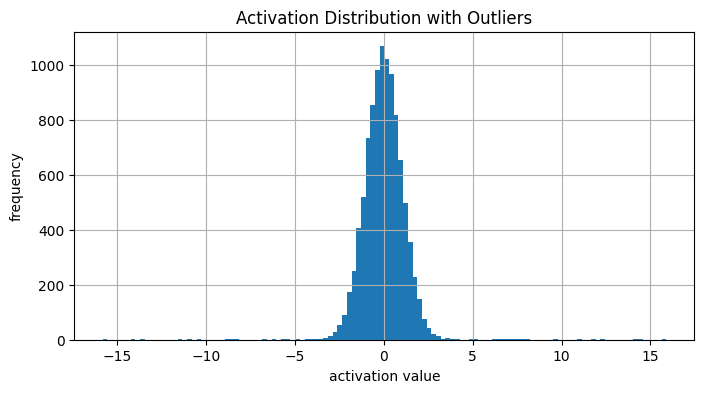

In [ ]:
# Activation 분포 보기
plt.figure(figsize=(8, 4))
plt.hist(x, bins=120)
plt.title("Activation Distribution with Outliers")
plt.xlabel("activation value")
plt.ylabel("frequency")
plt.grid(True)
plt.show()

- 양자화 함수 구현
    - 8-bit symmetric quantization
    - symmetric quantization에서는 보통 zero-point를 0으로 두고, 절댓값 최대치로 scale을 정함.

In [ ]:
def symmetric_quantize(x, alpha, num_bits=8):
    qmax = 2**(num_bits - 1) - 1   # int8이면 127
    qmin = -qmax                   # -127

    scale = alpha / qmax
    scale = max(scale, 1e-12)

    q = np.round(x / scale)
    q_clipped = np.clip(q, qmin, qmax)
    x_hat = q_clipped * scale

    return q_clipped, x_hat, scale

In [ ]:
# 평가 함수 구현
## 양자화 오차와 clipping 손실 사이의 균형
def evaluate_quantization(x, x_hat, alpha):
    mse = np.mean((x - x_hat) ** 2)
    clip_ratio = np.mean(np.abs(x) > alpha)
    max_abs_error = np.max(np.abs(x - x_hat))
    return mse, clip_ratio, max_abs_error

In [ ]:
# Min-max Calibration
## 전체 데이터의 최소/최대, 여기서는 symmetric이므로 절댓값 최대치를 사용

alpha_minmax = np.max(np.abs(x))

q_mm, xhat_mm, scale_mm = symmetric_quantize(x, alpha_minmax, num_bits=8)
mse_mm, clip_mm, maxerr_mm = evaluate_quantization(x, xhat_mm, alpha_minmax)

print("[Min-Max Calibration]")
print("alpha      =", alpha_minmax)
print("scale      =", scale_mm)
print("MSE        =", mse_mm)
print("clip ratio =", clip_mm)
print("max error  =", maxerr_mm)

[Min-Max Calibration]
alpha      = 15.885411288118718
scale      = 0.1250819786466041
MSE        = 0.001315497417458964
clip ratio = 0.0
max error  = 0.06252903305866564


In [ ]:
#Percentile calibration
#극단적인 outlier를 일부 무시하고 범위를 잡자.
##Percentile calibration은 outlier 영향을 줄이는 대신, 잘린 값은 clipping이 될 수 있음

percentile = 99.5
alpha_pct = np.percentile(np.abs(x), percentile)

q_pct, xhat_pct, scale_pct = symmetric_quantize(x, alpha_pct, num_bits=8)
mse_pct, clip_pct, maxerr_pct = evaluate_quantization(x, xhat_pct, alpha_pct)

print(f"[Percentile Calibration: {percentile}%]")
print("alpha      =", alpha_pct)
print("scale      =", scale_pct)
print("MSE        =", mse_pct)
print("clip ratio =", clip_pct)
print("max error  =", maxerr_pct)

[Percentile Calibration: 99.5%]
alpha      = 3.78610811623829
scale      = 0.02981187493101016
MSE        = 0.14904137385433158
clip ratio = 0.00505952380952381
max error  = 12.099303171880427


In [ ]:
# 결과 비교
print("=== Comparison ===")
print(f"{'Method':<20} {'Alpha':>12} {'Scale':>12} {'MSE':>12} {'ClipRatio':>12}")
print("-" * 72)
print(f"{'Min-Max':<20} {alpha_minmax:>12.4f} {scale_mm:>12.6f} {mse_mm:>12.6f} {clip_mm:>12.6f}")
print(f"{f'Percentile {percentile}%':<20} {alpha_pct:>12.4f} {scale_pct:>12.6f} {mse_pct:>12.6f} {clip_pct:>12.6f}")

=== Comparison ===
Method                      Alpha        Scale          MSE    ClipRatio
------------------------------------------------------------------------
Min-Max                   15.8854     0.125082     0.001315     0.000000
Percentile 99.5%           3.7861     0.029812     0.149041     0.005060


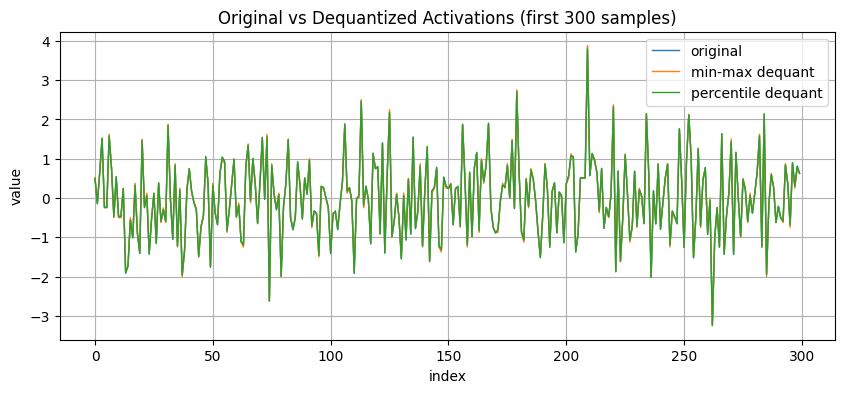

In [ ]:
# 복원값 비교 시각화
idx = np.arange(300)

plt.figure(figsize=(10, 4))
plt.plot(idx, x[:300], label="original", linewidth=1)
plt.plot(idx, xhat_mm[:300], label="min-max dequant", linewidth=1)
plt.plot(idx, xhat_pct[:300], label="percentile dequant", linewidth=1)
plt.title("Original vs Dequantized Activations (first 300 samples)")
plt.xlabel("index")
plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.show()

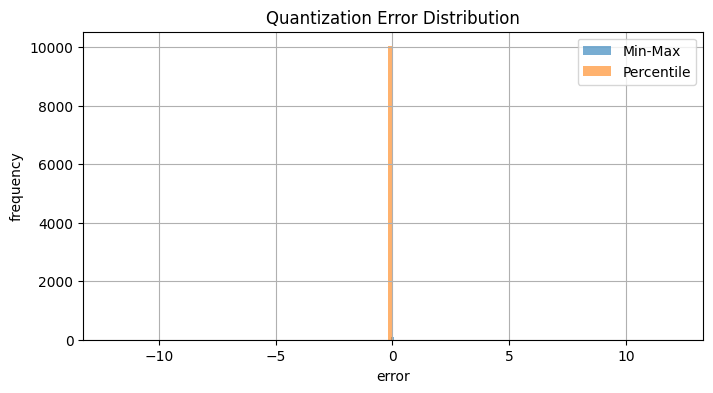

In [ ]:
# error 분포 비교
err_mm = x - xhat_mm
err_pct = x - xhat_pct

plt.figure(figsize=(8, 4))
plt.hist(err_mm, bins=100, alpha=0.6, label="Min-Max")
plt.hist(err_pct, bins=100, alpha=0.6, label="Percentile")
plt.title("Quantization Error Distribution")
plt.xlabel("error")
plt.ylabel("frequency")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# percentile을 바꿔가며 실험

percentiles = [99.0, 99.5, 99.9, 99.95, 100.0]

results = []

for p in percentiles:
    alpha = np.percentile(np.abs(x), p) if p < 100.0 else np.max(np.abs(x))
    _, xhat, scale = symmetric_quantize(x, alpha, num_bits=8)
    mse, clip_ratio, _ = evaluate_quantization(x, xhat, alpha)
    results.append((p, alpha, scale, mse, clip_ratio))

print(f"{'Percentile':<12} {'Alpha':>12} {'Scale':>12} {'MSE':>12} {'ClipRatio':>12}")
print("-" * 72)
for p, alpha, scale, mse, clip_ratio in results:
    print(f"{p:<12} {alpha:>12.4f} {scale:>12.6f} {mse:>12.6f} {clip_ratio:>12.6f}")

Percentile          Alpha        Scale          MSE    ClipRatio
------------------------------------------------------------------------
99.0               2.8969     0.022811     0.191682     0.010020
99.5               3.7861     0.029812     0.149041     0.005060
99.9              10.9151     0.085946     0.010490     0.001091
99.95             13.6298     0.107321     0.002051     0.000595
100.0             15.8854     0.125082     0.001315     0.000000


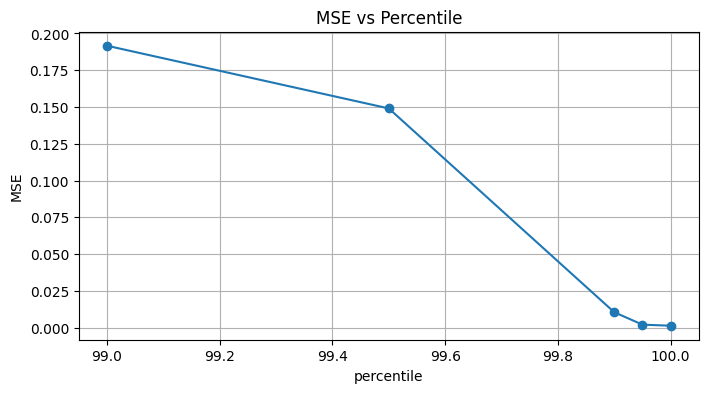

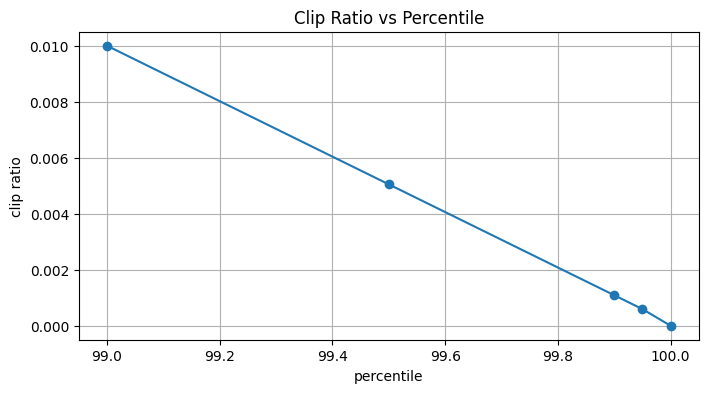

In [ ]:
#percentile별 MSE 시각화

ps = [r[0] for r in results]
mses = [r[3] for r in results]
clips = [r[4] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(ps, mses, marker='o')
plt.title("MSE vs Percentile")
plt.xlabel("percentile")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(ps, clips, marker='o')
plt.title("Clip Ratio vs Percentile")
plt.xlabel("percentile")
plt.ylabel("clip ratio")
plt.grid(True)
plt.show()

# 8. 클리핑(Clipping)과 아웃라이어 처리

양자화에서는 **소수의 큰 값(outlier)** 이 전체 scale을 과도하게 키워서, 실제로 자주 등장하는 **대부분의 작은 값들이 거칠게 양자화되는 문제**가 자주 발생.

예를 들어 activation의 대부분이 \([-1,1]\) 안에 있지만, 극히 일부 값만 $10$ 근처까지 튄다고 해보자.

이 경우 단순 min-max 범위를 사용하면 그 큰 값들 때문에 scale이 커지고, 결과적으로 $[-1,1]$ 근처의 값들은 정수 격자 위에서 너무 성기게 표현됨.

그래서 실무에서는 단순히 최소값과 최대값만 쓰지 않고, 다음과 같은 기법을 함께 사용.

- min-max clipping
- percentile clipping
- outlier 분리 처리
- channel별 별도 scale

특히 LLM에서는 일부 채널이나 일부 token 위치에서 매우 큰 activation이 튀는 경우가 있어, 이런 처리가 더 중요.

---

## 1. 기본 양자화 식

실수값 $x$ 를 정수값 $q$ 로 양자화하는 대표적인 식은 다음과 같음.

$$
q = \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s}\right) + z,\;
q_{\min}, q_{\max}
\right)
$$

복원값(dequantized value)은

$$
\hat{x} = s(q-z)
$$

- $x$: 원래 실수값
- $q$: 양자화된 정수값
- $\hat{x}$: 복원된 값
- $s$: scale
- $z$: zero-point
- $q_{\min}, q_{\max}$: 정수 범위


예를 들어 int8이면 보통

$$
q_{\min} = -128,\qquad q_{\max}=127
$$

또는 symmetric quantization에서는

$$
q_{\min}=-127,\qquad q_{\max}=127
$$

를 사용.

---

## 2. 아웃라이어가 왜 문제인가?

양자화에서 scale은 보통 실수 범위를 정수 범위에 맞춰 나누는 역할을 함.


예를 들어 asymmetric quantization에서는 대체로

$$
s = \frac{x_{\max}-x_{\min}}{q_{\max}-q_{\min}}
$$

처럼 정함.

symmetric quantization에서는 절댓값 최대치 $\alpha$ 를 써서

$$
\alpha = \max(|x_{\min}|, |x_{\max}|)
$$

$$
s = \frac{\alpha}{q_{\max}}
$$

처럼 둠.

문제는 outlier 때문에 $\alpha$ 가 너무 커질 수 있다는 점입니다.

예를 들어 대부분 값이 $[-1,1]$ 안에 있는데, 극소수 값이 $\pm 10$ 이라면

$$
\alpha = 10
$$

이 되고 int8 symmetric quantization에서는

$$
s = \frac{10}{127} \approx 0.0787
$$

이 됨.

그러면 $[-1,1]$ 구간 안에서 표현 가능한 정수 단계 수는 대략

$$
\frac{1}{0.0787} \approx 12.7
$$

수준밖에 되지 않음.  

-> 작은 값들이 매우 거칠게 양자화됨.

반면 outlier를 무시하고 $\alpha=1$ 로 잡으면

$$
s = \frac{1}{127} \approx 0.00787
$$

가 되어 훨씬 더 세밀한 표현이 가능.

---

## 3. 클리핑(Clipping)이란?

클리핑은 **일정 범위를 넘는 값들을 잘라내는 것**.

예를 들어 threshold를 $\alpha$ 로 두면,

$$
x_{\text{clip}} = \operatorname{clip}(x,\; -\alpha,\; \alpha)
$$


$$
x_{\text{clip}} =
\begin{cases}
-\alpha, & x < -\alpha \\
x, & -\alpha \le x \le \alpha \\
\alpha, & x > \alpha
\end{cases}
$$

이렇게 하면 소수의 outlier가 전체 scale을 망치는 것을 막을 수 있음.

하지만 그 대신 $|x| > \alpha$ 인 값들은 정보 손실이 생김.  

-> 클리핑은 다음 두 가지 사이의 trade-off입니다.

- 범위를 넓게 잡으면: clipping은 적지만 resolution이 나빠짐
- 범위를 좁게 잡으면: resolution은 좋아지지만 clipping이 많아짐

---

## 4. Quantization Error와 Clipping Error

양자화 후 오차는 보통

$$
e = x - \hat{x}
$$

로 정의할 수 있음.

전체 평균 제곱 오차(MSE)는

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}(x_i - \hat{x}_i)^2
$$

이 오차는 크게 두 종류로 생각할 수 있음.


### (1) 양자화 해상도 오차
범위가 너무 넓어서 scale이 커지면, 작은 값들이 듬성듬성 표현되어 오차가 커짐.

### (2) 클리핑 오차
범위를 너무 좁게 잡으면 큰 값들이 잘려서 오차가 커짐.

clipping threshold를 정하는 일은 결국

$$
\min_{\alpha} \sum_i (x_i - \hat{x}_i(\alpha))^2
$$

같은 문제로 볼 수 있습니다.

---

## 5. Min-Max Clipping

가장 단순한 방법은 관측된 최소값, 최대값을 그대로 쓰는 것입니다.

$$
x \in [x_{\min}, x_{\max}]
$$

또는 symmetric하게

$$
\alpha = \max(|x_{\min}|, |x_{\max}|)
$$

를 사용.

이 방식의 장점은 단순.

- 구현이 가장 쉬움
- clipping이 거의 없음
- calibration 과정이 단순함

하지만 단점도 큼.

- outlier에 매우 민감함
- 소수의 큰 값 때문에 scale이 커질 수 있음
- 대부분의 값 표현 정밀도가 낮아질 수 있음

min-max는 안정적이지만 outlier가 있을 때 비효율적일 수 있음.

---

## 6. Percentile Clipping

outlier 영향을 줄이기 위해 자주 쓰는 방법이 percentile clipping입니다.

예를 들어 절댓값 분포에서 상위 일부를 잘라내고 범위를 정합니다.

$$
\alpha = \operatorname{Percentile}(|x|, p)
$$

예를 들어 $p=99.9\%$ 이면,

$$
\alpha = \operatorname{Percentile}(|x|, 99.9)
$$

로 두고

$$
x_{\text{clip}} = \operatorname{clip}(x, -\alpha, \alpha)
$$

를 사용.

장점:

- 극단적인 outlier 영향을 줄일 수 있음
- 대부분의 값에 대해 더 좋은 resolution 확보 가능
- 실무에서 매우 자주 사용됨

단점:

- 잘려나간 값은 손실 발생
- percentile 선택이 성능에 영향을 줌
- 데이터 분포가 바뀌면 최적 percentile도 달라질 수 있음

percentile clipping은 **소수의 큰 값을 희생해서, 대부분의 값 표현력을 높이는 전략**.

---

## 7. Outlier 분리 처리

일부 값만 유난히 크다면, 그 값들을 일반적인 양자화 경로에서 분리해서 처리할 수 있습니다.

예를 들어 벡터 $x$ 에 대해 threshold $\tau$ 를 정하고,

$$
x = x_{\text{normal}} + x_{\text{outlier}}
$$

로 나눌 수 있음.

여기서

$$
x_{\text{normal}} =
\begin{cases}
x, & |x| \le \tau \\
0, & |x| > \tau
\end{cases}
$$

$$
x_{\text{outlier}} =
\begin{cases}
0, & |x| \le \tau \\
x, & |x| > \tau
\end{cases}
$$


그 다음

- $x_{\text{normal}}$: 일반적인 int8 또는 low-bit quantization 적용
- $x_{\text{outlier}}$: FP16, FP32, 또는 별도 high-precision 경로로 처리

를 할 수 있습니다.

이 방식의 핵심은 **대부분의 값은 저비트로 효율적으로 처리하면서, 극단적으로 큰 값만 따로 보호하는 것**.

장점:

- 전체 scale이 outlier에 끌려가지 않음
- 대부분 값에 대해 더 세밀한 양자화 가능
- 중요한 큰 값 정보 손실을 줄일 수 있음

단점:

- 구현이 복잡해짐
- 별도 경로 계산 비용이 듦
- 하드웨어/커널 최적화가 필요할 수 있음

LLM quantization에서 outlier-aware quantization이 중요한 이유가 여기에 있음.

---

## 8. Channel별 별도 Scale

하나의 tensor 전체에 대해 scale 하나만 쓰는 대신, channel마다 다른 scale을 둘 수 있습니다.

예를 들어 weight tensor가 채널 $c$ 에 대해 나뉜다면,

$$
W^{(c)}
$$

각 채널마다 별도로

$$
\alpha^{(c)} = \max |W^{(c)}|
$$

$$
s^{(c)} = \frac{\alpha^{(c)}}{q_{\max}}
$$

를 둘 수 있음.

그러면 양자화는

$$
q^{(c)} = \operatorname{clip}\left(
\operatorname{round}\left(\frac{W^{(c)}}{s^{(c)}}\right),
-q_{\max}, q_{\max}
\right)
$$

로 수행됨.

이 방법은 흔히 **per-channel quantization** 이라고 부름.

장점:

- 채널마다 분포 차이를 반영할 수 있음
- 특정 채널의 outlier가 다른 채널까지 망치지 않음
- 정확도가 훨씬 좋아지는 경우가 많음

단점:

- scale 저장이 더 필요함
- 구현과 연산이 다소 복잡해짐

특히 LLM에서는 일부 채널만 매우 큰 값을 가지는 경우가 있어, per-tensor보다 per-channel이 훨씬 유리한 경우가 많습니다.

---

## 9. 왜 LLM에서 더 중요할까?

LLM에서는 activation이나 weight에서 특정 채널이 유난히 큰 값을 가지는 경우가 자주 관찰됨.

예를 들어 hidden state $h \in \mathbb{R}^d$ 에서 일부 성분만 매우 크다고 하면,

$$
h = [0.2,\; -0.1,\; 0.4,\; 12.8,\; -0.3,\; 0.1,\dots]
$$

처럼 소수 성분만 튈 수 있다.

이때 전체 벡터에 scale 하나만 쓰면 $12.8$ 때문에 scale이 커지고, 나머지 작은 값들은 정밀도를 잃습니다.

LLM에서는 다음 문제가 더 두드러집니다.

- 특정 채널 outlier
- token별 activation 분포 차이
- layer별 분포 차이
- attention/MLP block마다 다른 스케일 구조

그래서 다음이 더 중요해짐.

- percentile clipping
- outlier-aware quantization
- per-channel quantization
- group-wise quantization

---

## 10. Group-wise Quantization

per-channel보다 조금 더 단순한 중간 방식으로는 group-wise quantization도 있습니다.

예를 들어 채널들을 몇 개씩 묶어서 그룹 $g$ 를 만들고,

$$
\alpha^{(g)} = \max_{i \in g} |x_i|
$$

$$
s^{(g)} = \frac{\alpha^{(g)}}{q_{\max}}
$$

처럼 그룹별 scale을 둠.

장점:

- per-tensor보다 정확도 좋음
- per-channel보다 저장 및 구현 부담이 적을 수 있음

**per-tensor와 per-channel 사이의 절충안**으로 볼 수 있음.

---

## 11. 클리핑 임계값을 어떻게 정하나?

클리핑 threshold $\alpha$ 를 정하는 대표 방법은 다음과 같습니다.

### (1) Min-Max
$$
\alpha = \max |x|
$$

### (2) Percentile
$$
\alpha = \operatorname{Percentile}(|x|, p)
$$

### (3) MSE 최소화 기반
여러 후보 $\alpha$ 중에서

$$
\alpha^* = \arg\min_{\alpha} \sum_i (x_i - \hat{x}_i(\alpha))^2
$$

가 되는 값을 선택

### (4) Histogram 기반
activation histogram을 만들고, 분포 보존이 잘 되는 $\alpha$ 를 선택

클리핑 threshold 선택은 단순 휴리스틱이 아니라 **양자화 오차를 최소화하는 최적화 문제**로 볼 수 있다.



- 실습

$$
x_{clip} = clip(x,-\alpha,\alpha)
$$

과 MSE 기준

\$$
min_{\alpha} \sum_i (x_i - \hat{x_i}(\alpha))^2
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# LLM activation처럼 outlier-heavy 데이터
np.random.seed(0)

# 대부분 작은 activation
normal = np.random.normal(0, 0.5, 10000)

# 큰 outlier
outliers = np.random.normal(0, 8.0, 50)

x = np.concatenate([normal, outliers])

print("shape:", x.shape)
print("min:", x.min())
print("max:", x.max())

shape: (10050,)
min: -22.425872677159898
max: 16.567179279236072


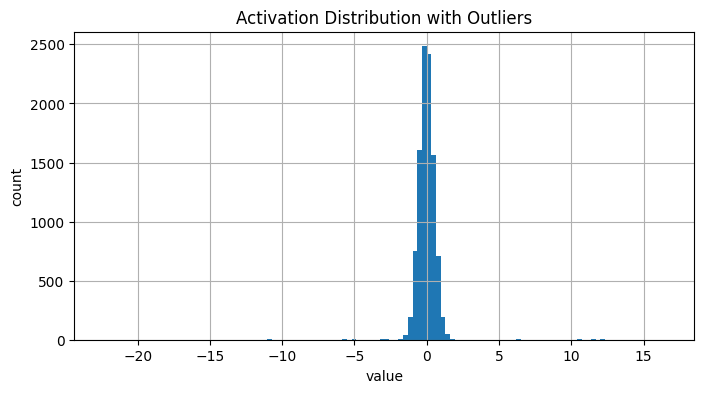

In [ ]:
#분포 시각화
plt.figure(figsize=(8,4))
plt.hist(x, bins=120)
plt.title("Activation Distribution with Outliers")
plt.xlabel("value")
plt.ylabel("count")
plt.grid(True)
plt.show()

In [ ]:
# Symmetric quantization
def quantize_symmetric(x, alpha, bits=8):
    qmax = 2**(bits-1)-1
    scale = alpha / qmax
    scale = max(scale, 1e-12)

    q = np.round(x / scale)
    q = np.clip(q, -qmax, qmax)

    x_hat = q * scale
    return x_hat, scale

In [ ]:
# Min-Max quantization
alpha_mm = np.max(np.abs(x))
xhat_mm, scale_mm = quantize_symmetric(x, alpha_mm)

mse_mm = np.mean((x - xhat_mm)**2)

print("[Min-Max]")
print("alpha:", alpha_mm)
print("scale:", scale_mm)
print("MSE:", mse_mm)

[Min-Max]
alpha: 22.425872677159898
scale: 0.1765816746233063
MSE: 0.002626257292545496


In [ ]:
# Percentile clipping
p = 99.5
alpha_pct = np.percentile(np.abs(x), p)

x_clip = np.clip(x, -alpha_pct, alpha_pct)
xhat_pct, scale_pct = quantize_symmetric(x_clip, alpha_pct)

mse_pct = np.mean((x - xhat_pct)**2)

print("[Percentile]")
print("alpha:", alpha_pct)
print("scale:", scale_pct)
print("MSE:", mse_pct)

[Percentile]
alpha: 1.5619559903564393
scale: 0.012298866065798735
MSE: 0.20689712577252786


In [ ]:
#결과 비교
print("=== Comparison ===")
print("Min-Max MSE      :", mse_mm)
print("Percentile MSE   :", mse_pct)

=== Comparison ===
Min-Max MSE      : 0.002626257292545496
Percentile MSE   : 0.20689712577252786


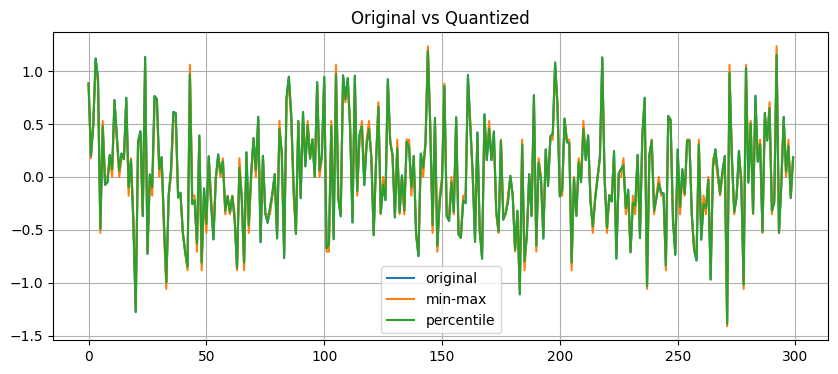

In [ ]:
#시각화 비교
idx = np.arange(300)

plt.figure(figsize=(10,4))
plt.plot(idx, x[:300], label="original")
plt.plot(idx, xhat_mm[:300], label="min-max")
plt.plot(idx, xhat_pct[:300], label="percentile")
plt.legend()
plt.grid(True)
plt.title("Original vs Quantized")
plt.show()

In [ ]:
#Outlier 분리 처리 실습
## 큰 값만 따로 FP32로 남기고 나머지만 int8로 감
tau = 2.0

normal_part = np.where(np.abs(x) <= tau, x, 0)
outlier_part = np.where(np.abs(x) > tau, x, 0)

alpha_normal = np.max(np.abs(normal_part))
xhat_normal, scale_normal = quantize_symmetric(normal_part, alpha_normal)

# outlier는 그대로 보존
xhat_outlier = xhat_normal + outlier_part

mse_outlier = np.mean((x - xhat_outlier)**2)

print("[Outlier Aware]")
print("threshold:", tau)
print("MSE:", mse_outlier)

[Outlier Aware]
threshold: 2.0
MSE: 1.9692473068043686e-05


In [ ]:
# per-channel quantization
X = np.random.normal(0, 0.5, (1000, 8))
X[:, 3] *= 10   # 특정 채널 outlier

In [ ]:
# 1. per-tensor
alpha_tensor = np.max(np.abs(X))
Xhat_tensor, _ = quantize_symmetric(X, alpha_tensor)

mse_tensor = np.mean((X - Xhat_tensor)**2)
print("Per-Tensor MSE:", mse_tensor)

Per-Tensor MSE: 0.0015574084135854943


In [ ]:
# 2. per-channel
Xhat_channel = np.zeros_like(X)

for c in range(X.shape[1]):
    alpha_c = np.max(np.abs(X[:, c]))
    Xhat_channel[:, c], _ = quantize_symmetric(X[:, c], alpha_c)

mse_channel = np.mean((X - Xhat_channel)**2)
print("Per-Channel MSE:", mse_channel)

Per-Channel MSE: 0.00020945558044077584


- Threshold sweep
    - 어느 clipping threshold가 좋은지 자동 탐색

$$
\alpha^{*} = arg min_{\alpha} \sum_i (x_i -\hat{x_i}(\alpha))^2
$$


In [ ]:
alphas = np.linspace(0.5, 10, 40)
mses = []

for a in alphas:
    x_clip = np.clip(x, -a, a)
    xhat, _ = quantize_symmetric(x_clip, a)
    mse = np.mean((x - xhat)**2)
    mses.append(mse)

best_alpha = alphas[np.argmin(mses)]
print("best alpha:", best_alpha)

best alpha: 10.0


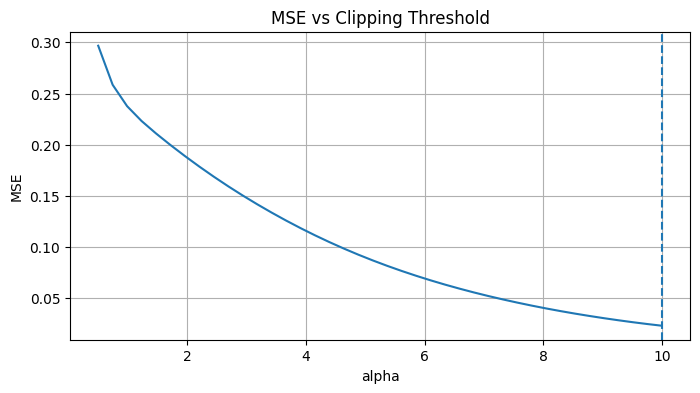

In [ ]:
# 최적 threshold 시각화
plt.figure(figsize=(8,4))
plt.plot(alphas, mses)
plt.axvline(best_alpha, linestyle='--')
plt.title("MSE vs Clipping Threshold")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# 9. 딥러닝에서 자주 쓰이는 양자화 방식들

딥러닝에서 양자화(quantization)는 모델의 **가중치(weights)** 와 **활성값(activations)** 을 FP32 같은 고정밀 실수 대신 INT8, INT4 같은 저비트 표현으로 바꾸어

- 메모리 사용량 감소
- 추론 속도 향상
- 배포 효율 향상
- 전력 소모 감소

를 얻기 위한 방법.

양자화는 단순히 숫자 타입만 바꾸는 것이 아니라, **어떤 값을**, **언제**, **어떤 범위로**, **어떤 정밀도로** 바꿀지를 결정하는 설계 문제.

---

## 1. 기본 양자화 식

실수값 $x$ 를 정수값 $q$ 로 바꾸는 기본 식은 보통 다음과 같습니다.

$$
q = \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s}\right) + z,\;
q_{\min}, q_{\max}
\right)
$$

복원은

$$
\hat{x} = s(q-z)
$$

입니다.

여기서

- $x$: 원래 실수값
- $q$: 양자화된 정수값
- $\hat{x}$: 복원된 값
- $s$: scale
- $z$: zero-point
- $q_{\min}, q_{\max}$: 정수 범위

예를 들어 INT8이면 보통

$$
q_{\min}=-128,\qquad q_{\max}=127
$$

또는 symmetric quantization에서는

$$
q_{\min}=-127,\qquad q_{\max}=127
$$

를 사용.

---

## 2. 양자화 방식은 무엇이 다른가?

양자화 방식들은 보통 다음 기준에서 차이가 남.

- **언제 양자화하나?**
  - 학습 후
  - 학습 중
  - 추론 시점에 동적으로

- **무엇을 양자화하나?**
  - weight만
  - activation만
  - 둘 다

- **어디에 적용하나?**
  - 전체 tensor
  - channel별
  - group별

- **얼마나 정밀하게 하나?**
  - INT8
  - INT4
  - NF4
  - FP16과 혼합

---

# (1) Dynamic Quantization

## 개념

Dynamic Quantization은 **가중치는 미리 양자화해 두고**, **activation은 추론 시점에 동적으로 범위를 계산하여 양자화**하는 방식.


- weight: 사전에 INT8 등으로 변환
- activation: 입력이 들어올 때마다 scale을 계산해서 양자화

하는 구조.

주로 **NLP 모델의 Linear layer** 에 쉽게 적용되며, 특히 CPU 추론에서 자주 사용됨.

---

## 수식 관점

입력 activation $x$ 와 weight $W$ 가 있을 때, 선형 연산은 원래

$$
y = Wx + b
$$

입니다.

Dynamic Quantization에서는 weight $W$ 는 미리 양자화된 $q_W$ 로 저장하고,  
입력 $x$ 는 추론 시점에 scale $s_x$ 를 계산하여 양자화합니다.

$$
q_x = \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s_x}\right),
q_{\min}, q_{\max}
\right)
$$

$$
q_W = \operatorname{clip}\left(
\operatorname{round}\left(\frac{W}{s_W}\right),
q_{\min}, q_{\max}
\right)
$$

정수 연산 후 복원은 대략

$$
\hat{y} \approx s_W s_x (q_W q_x) + b
$$

처럼 볼 수 있음.

---

## 특징

### 장점
- 적용이 매우 쉬움
- calibration dataset이 필요 없음
- CPU에서 빠르게 적용 가능
- 특히 transformer의 Linear layer에 잘 맞음

### 단점
- activation scale을 매번 계산해야 함
- static quantization보다 최적화가 덜 될 수 있음
- CNN 배포에서는 static보다 덜 강력한 경우가 많음

---

## 언제 자주 쓰나?
- BERT, LSTM, Transformer encoder류 CPU 추론
- 빠르게 baseline 양자화를 해보고 싶을 때
- 학습 없이 바로 배포 최적화하고 싶을 때

---

# (2) Static Quantization

## 개념

Static Quantization은 **weight와 activation 모두를 미리 양자화 설정해 두는 방식**.

- calibration dataset으로 activation 범위를 미리 추정
- 그 범위로 scale/zero-point를 고정
- 추론 시에는 정수 연산 위주로 실행


이 방식은 특히 **CNN, CV 모델 배포**에서 자주 사용됩니다.

---

## 수식 관점

입력 activation의 범위를 calibration으로 추정해서

$$
x \in [x_{\min}, x_{\max}]
$$

를 얻고, 이를 바탕으로 scale과 zero-point를 계산.

asymmetric quantization이면

$$
s_x = \frac{x_{\max}-x_{\min}}{q_{\max}-q_{\min}}
$$

$$
z_x = \operatorname{round}\left(q_{\min} - \frac{x_{\min}}{s_x}\right)
$$

weight도 마찬가지로

$$
s_W = \frac{W_{\max}-W_{\min}}{q_{\max}-q_{\min}}
$$

$$
z_W = \operatorname{round}\left(q_{\min} - \frac{W_{\min}}{s_W}\right)
$$

를 계산할 수 있음.

그 후

$$
q_x = \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s_x}\right)+z_x,
q_{\min}, q_{\max}
\right)
$$

$$
q_W = \operatorname{clip}\left(
\operatorname{round}\left(\frac{W}{s_W}\right)+z_W,
q_{\min}, q_{\max}
\right)
$$

로 양자화하여 추론에 사용.

---

## 특징

### 장점
- 실제 하드웨어 가속 효과가 큼
- activation까지 정수화되므로 효율이 좋음
- CNN inference에서 매우 강력함

### 단점
- calibration 필요
- activation 분포가 calibration 데이터와 다르면 정확도 저하 가능
- 설정이 dynamic보다 복잡함

---

## 언제 자주 쓰나?
- 모바일/엣지 CNN 배포
- 컴퓨터 비전 모델의 INT8 inference
- production inference optimization

---

# (3) QAT (Quantization-Aware Training)

## 개념

QAT는 **학습 중에 양자화를 고려하면서 훈련하는 방식**.

학습 중 forward에서는 실제로 양자화된 것처럼 동작하게 만들고, backward에서는 gradient가 흐를 수 있도록 근사를 사용.

보통 **fake quantization** 을 삽입.

---

## 핵심 아이디어

실제 양자화 연산

$$
q = \operatorname{round}\left(\frac{x}{s}\right)
$$

은 미분이 거의 불가능.


그래서 backward에서는 보통 **STE(Straight-Through Estimator)** 를 사용.

forward에서는

$$
\hat{x} = s \cdot \operatorname{clip}\left(
\operatorname{round}\left(\frac{x}{s}\right),
q_{\min}, q_{\max}
\right)
$$

처럼 fake quantization을 수행하고, backward에서는 근사적으로

$$
\frac{\partial \hat{x}}{\partial x} \approx 1
$$

로 두어 gradient를 통과시킴.

---

## 왜 좋은가?

PTQ(Post-Training Quantization)는 학습이 끝난 뒤 양자화하므로 모델이 양자화 오차를 미리 경험하지 못함.

반면 QAT에서는 학습 중부터 양자화 오차를 반영하므로 모델 파라미터가 그 오차를 견디는 방향으로 적응합니다.

즉, 이상적으로는 다음을 학습한다고 볼 수 있습니다.

$$
\min_{\theta} \mathcal{L}(f_{\text{quant}}(x;\theta), y)
$$

여기서 $f_{\text{quant}}$ 는 양자화 효과가 포함된 모델입니다.

---

## 특징

### 장점
- 정확도 유지에 가장 유리한 경우가 많음
- INT8, INT4 등 저비트 환경에서 PTQ보다 안정적
- 모바일/엣지 배포에 매우 적합

### 단점
- 다시 학습해야 함
- 구현이 더 복잡함
- 훈련 시간과 비용이 증가

---

## 언제 자주 쓰나?
- 정확도 손실을 최소화해야 할 때
- low-bit quantization이 필요한 배포
- PTQ만으로 성능 저하가 클 때

---

# (4) Weight-only Quantization

## 개념

Weight-only Quantization은 **가중치만 양자화하고 activation은 float로 유지하는 방식**.

- weight: INT8, INT4, NF4 등 저비트 저장
- activation: FP16, BF16, FP32 유지

입니다.

이 방식은 **LLM 추론에서 매우 흔합니다.**

왜냐하면 LLM에서는 activation까지 매우 낮은 비트로 양자화하면 정확도 저하가 커질 수 있기 때문.

---

## 수식 관점

원래 선형 연산은

$$
y = Wx
$$


여기서 $W$ 만 양자화하여

$$
W \approx \hat{W} = s_W(q_W-z_W)
$$

로 바꾸면,

$$
y \approx \hat{W}x
$$

로 계산.

activation $x$ 는 여전히 float이고, weight만 compressed form으로 저장 및 복원하여 사용.

group-wise quantization까지 포함하면 각 그룹 $g$ 에 대해

$$
W^{(g)} \approx s^{(g)} q^{(g)}
$$

처럼 표현할 수 있다.

---

## 왜 LLM에서 자주 쓰나?

LLM에서는 weight가 메모리의 대부분을 차지.  

예를 들어 수십억 개 파라미터를 가진 모델에서 weight만 줄여도 메모리 절감 효과가 매우 큼.

또한 activation은 입력 길이, batch size에 따라 달라지고 attention이나 residual 구조 때문에 민감하기 때문에 activation을 float로 두는 것이 안정적.

---

## NF4는 무엇인가?

QLoRA에서 자주 나오는 NF4는 **NormalFloat4** 로, 정규분포에 잘 맞도록 설계된 4-bit 표현.

일반적인 선형 양자화처럼 균등 간격이 아니라,  
가중치가 정규분포 근처에 있다는 가정 아래 더 효율적으로 값을 배치함.

일반 INT4보다 weight 분포에 더 잘 맞도록 만든 4-bit codebook이라고 볼 수 있다.

수학적으로는 균일 quantizer

$$
q = \operatorname{round}\left(\frac{x}{s}\right)
$$

대신, 코드북 $C=\{c_1,\dots,c_{16}\}$ 중 가장 가까운 값을 고르는 방식으로 생각할 수 있습니다.

$$
q(x) = \arg\min_{c_i \in C} |x-c_i|
$$

---

## 특징

### 장점
- 메모리 절감 효과 큼
- LLM inference에서 매우 실용적
- activation을 float로 유지하므로 안정적
- INT4/NF4까지 확장 가능

### 단점
- activation memory는 그대로
- activation 연산 가속은 제한적
- hardware kernel 최적화에 따라 속도 이점이 달라짐

---

## 언제 자주 쓰나?
- LLM 로컬 추론
- GPU 메모리가 부족할 때
- QLoRA, GPTQ, AWQ 같은 계열

---

# (5) Mixed Precision + Quantization

## 개념

Mixed Precision + Quantization은 모든 layer를 동일한 정밀도로 처리하지 않고,  **민감한 부분은 FP16/BF16**, 덜 민감한 부분은 **INT8/INT4** 로 처리하는 방식.

정밀도를 섞어서 사용.

예를 들어

- embedding: FP16
- attention projection: INT8
- 일부 outlier-sensitive layer: BF16
- MLP weight: INT4

처럼 구성할 수 있다.

---

## 수식 관점

모델을 여러 부분으로 나누어

$$
f(x) = f_L \circ f_{L-1} \circ \cdots \circ f_1(x)
$$

라고 할 때, 각 layer $f_\ell$ 에 대해 서로 다른 정밀도를 할당.

예를 들어 어떤 layer는 float 근사

$$
f_\ell^{(\text{fp16})}(x)
$$

어떤 layer는 quantized 근사

$$
f_\ell^{(\text{int8})}(x)
$$

를 쓰는 식.

전체 모델은

$$
\hat{f}(x) =
f_L^{(p_L)} \circ f_{L-1}^{(p_{L-1})} \circ \cdots \circ f_1^{(p_1)}(x)
$$

처럼 쓸 수 있고,  

여기서 $p_\ell$ 는 각 layer의 precision 선택.

결국 목표는

$$
\min_{p_1,\dots,p_L} \text{Cost}(p_1,\dots,p_L)
$$

subject to

$$
\text{Accuracy drop} \le \epsilon
$$

같은 형태의 문제로 볼 수 있다.


**정확도 손실 제한 아래 메모리와 속도를 최적화하는 precision allocation 문제**.

---

## 왜 필요한가?

모든 layer가 동일하게 양자화에 강한 것은 아님.

예를 들어

- 첫 layer
- 마지막 layer
- attention output projection
- residual과 직접 연결되는 layer

는 더 민감할 수 있다.

이런 layer까지 무리하게 저비트로 내리면 정확도 손실이 커질 수 있음.

그래서 민감한 layer는 float 유지, 나머지만 quantize하는 방식이 자주 쓰임.

---

## 특징

### 장점
- 정확도와 효율 사이 절충이 좋음
- 민감한 layer 보호 가능
- 실제 LLM/vision 배포에서 유연하게 적용 가능

### 단점
- 어느 layer가 민감한지 분석 필요
- 구현과 스케줄링이 복잡함
- 하드웨어에 따라 성능 최적점이 달라짐

---

## 언제 자주 쓰나?
- 대형 모델 추론 최적화
- low-bit quantization을 공격적으로 하고 싶을 때
- 정확도 손실을 아주 작게 유지해야 할 때

In [1]:
import copy
import io
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
print(torch.__version__)
device = torch.device("cpu")
device
# 양자화 실습은 CPU에서 잘 동작하는 예제가 많음

2.10.0+cpu


device(type='cpu')

In [3]:
# 간단한 모델 준비 (작은 MLP)
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(16, 32)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 4)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model_fp32 = SimpleMLP().eval()
print(model_fp32)

SimpleMLP(
  (fc1): Linear(in_features=16, out_features=32, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=16, out_features=4, bias=True)
)


In [4]:
# 테스트 입력
x = torch.randn(8, 16)
with torch.no_grad():
    y_fp32 = model_fp32(x)

print("FP32 output shape:", y_fp32.shape)
print(y_fp32[:2])

FP32 output shape: torch.Size([8, 4])
tensor([[-0.2679, -0.0139, -0.2723,  0.0149],
        [-0.4582,  0.1165, -0.5097, -0.1654]])


In [5]:
# 모델 크기 측정 함수
def get_model_size_bytes(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return buffer.getbuffer().nbytes

def print_model_size(model, name="model"):
    size_mb = get_model_size_bytes(model) / (1024 ** 2)
    print(f"{name} size: {size_mb:.4f} MB")

In [6]:
print_model_size(model_fp32, "FP32 model")

FP32 model size: 0.0069 MB


- Dynamic Quantization
    - 주로 Linear layer에 쉽게 적용
    - weight는 양자화하고, activation은 실행 시점에 동적으로 처리하는 방식

In [7]:
dynamic_model = torch.quantization.quantize_dynamic(
    model_fp32,
    {nn.Linear},
    dtype=torch.qint8
)

/tmp/ipykernel_4924/1189431211.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  dynamic_model = torch.quantization.quantize_dynamic(


In [8]:
print(dynamic_model)
print_model_size(dynamic_model, "Dynamic quantized model")

SimpleMLP(
  (fc1): DynamicQuantizedLinear(in_features=16, out_features=32, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (relu1): ReLU()
  (fc2): DynamicQuantizedLinear(in_features=32, out_features=16, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (relu2): ReLU()
  (fc3): DynamicQuantizedLinear(in_features=16, out_features=4, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
)
Dynamic quantized model size: 0.0057 MB


In [9]:
with torch.no_grad():
    y_dynamic = dynamic_model(x)

print("FP32 output:")
print(y_fp32[:2])

print("\nDynamic Quant output:")
print(y_dynamic[:2])

diff_dynamic = torch.mean((y_fp32 - y_dynamic) ** 2).item()
print("\nDynamic Quant MSE vs FP32:", diff_dynamic)

FP32 output:
tensor([[-0.2679, -0.0139, -0.2723,  0.0149],
        [-0.4582,  0.1165, -0.5097, -0.1654]])

Dynamic Quant output:
tensor([[-0.2681, -0.0156, -0.2723,  0.0164],
        [-0.4582,  0.1183, -0.5108, -0.1649]])

Dynamic Quant MSE vs FP32: 3.49010019817797e-06


- 구현이 매우 간단함
- Linear layer 중심으로 잘 적용됨
- CPU 추론용 baseline으로 좋음

- Static Quantization 실습
    - Static Quantization은 activation range를 calibration으로 미리 정해야 합니다.
    - calibration dataset을 몇 번 흘려보내면서 activation 통계를 잡는 과정이 필요

In [10]:
class StaticMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.quant = torch.quantization.QuantStub()
        self.fc1 = nn.Linear(16, 32)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 4)
        self.dequant = torch.quantization.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.dequant(x)
        return x

In [11]:
static_model = StaticMLP().eval()
static_model.qconfig = torch.quantization.get_default_qconfig("fbgemm")
print(static_model.qconfig)

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})


In [12]:
static_prepared = torch.quantization.prepare(static_model)
print(static_prepared)

StaticMLP(
  (quant): QuantStub(
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (fc1): Linear(
    in_features=16, out_features=32, bias=True
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (relu1): ReLU()
  (fc2): Linear(
    in_features=32, out_features=16, bias=True
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (relu2): ReLU()
  (fc3): Linear(
    in_features=16, out_features=4, bias=True
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (dequant): DeQuantStub()
)


/tmp/ipykernel_4924/1000243595.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  static_prepared = torch.quantization.prepare(static_model)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future rel

In [14]:
# calibration / 대표 입력을 몇 번 흘려보냅니다.
for _ in range(20):
    calib_x = torch.randn(8, 16)
    static_prepared(calib_x)

In [15]:
# 이제 convert.
static_quantized = torch.quantization.convert(static_prepared)
print(static_quantized)
print_model_size(static_quantized, "Static quantized model")

StaticMLP(
  (quant): Quantize(scale=tensor([0.0538]), zero_point=tensor([59]), dtype=torch.quint8)
  (fc1): QuantizedLinear(in_features=16, out_features=32, scale=0.03863736614584923, zero_point=66, qscheme=torch.per_channel_affine)
  (relu1): ReLU()
  (fc2): QuantizedLinear(in_features=32, out_features=16, scale=0.014811583794653416, zero_point=77, qscheme=torch.per_channel_affine)
  (relu2): ReLU()
  (fc3): QuantizedLinear(in_features=16, out_features=4, scale=0.007152882404625416, zero_point=76, qscheme=torch.per_channel_affine)
  (dequant): DeQuantize()
)
Static quantized model size: 0.0083 MB


/tmp/ipykernel_4924/4218911814.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  static_quantized = torch.quantization.convert(static_prepared)


In [16]:
with torch.no_grad():
    y_static = static_quantized(x)

print("Static Quant output:")
print(y_static[:2])

diff_static = torch.mean((y_fp32 - y_static) ** 2).item()
print("\nStatic Quant MSE vs FP32:", diff_static)

Static Quant output:
tensor([[ 0.0572,  0.1860,  0.1431, -0.1788],
        [ 0.0286,  0.1717,  0.0930, -0.2575]])

Static Quant MSE vs FP32: 0.0637078583240509


- calibration이 필요함
- activation도 정수화 경로로 들어감
- 실제 배포용 양자화 구조를 이해하는 데 중요함

- QAT 실습
    - QAT는 학습 중 fake quantization을 삽입하여, 모델이 양자화 오차를 미리 경험하도록 하는 방법

In [17]:
class QATMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.quant = torch.quantization.QuantStub()
        self.fc1 = nn.Linear(16, 32)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 4)
        self.dequant = torch.quantization.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.dequant(x)
        return x

In [18]:
#QAT 모델 준비
qat_model = QATMLP()
qat_model.train()
qat_model.qconfig = torch.quantization.get_default_qat_qconfig("fbgemm")
qat_prepared = torch.quantization.prepare_qat(qat_model)
print(qat_prepared)

QATMLP(
  (quant): QuantStub(
    (activation_post_process): FusedMovingAvgObsFakeQuantize(
      fake_quant_enabled=tensor([1]), observer_enabled=tensor([1]), scale=tensor([1.]), zero_point=tensor([0], dtype=torch.int32), dtype=torch.quint8, quant_min=0, quant_max=127, qscheme=torch.per_tensor_affine, reduce_range=True
      (activation_post_process): MovingAverageMinMaxObserver(min_val=inf, max_val=-inf)
    )
  )
  (fc1): Linear(
    in_features=16, out_features=32, bias=True
    (weight_fake_quant): FusedMovingAvgObsFakeQuantize(
      fake_quant_enabled=tensor([1]), observer_enabled=tensor([1]), scale=tensor([1.]), zero_point=tensor([0], dtype=torch.int32), dtype=torch.qint8, quant_min=-128, quant_max=127, qscheme=torch.per_channel_symmetric, reduce_range=False
      (activation_post_process): MovingAveragePerChannelMinMaxObserver(min_val=tensor([]), max_val=tensor([]))
    )
    (activation_post_process): FusedMovingAvgObsFakeQuantize(
      fake_quant_enabled=tensor([1]), observ

/tmp/ipykernel_4924/1976719325.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qat_prepared = torch.quantization.prepare_qat(qat_model)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:534: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future releas

In [19]:
# toy example training
optimizer = torch.optim.Adam(qat_prepared.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for step in range(50):
    inp = torch.randn(16, 16)
    target = torch.randn(16, 4)

    optimizer.zero_grad()
    out = qat_prepared(inp)
    loss = loss_fn(out, target)
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        print(f"step={step}, loss={loss.item():.6f}")

step=0, loss=0.942761
step=10, loss=0.842987
step=20, loss=1.309062
step=30, loss=0.913836
step=40, loss=1.410715


In [20]:
# 학습이 끝나면 eval 후 convert 함
qat_prepared.eval()
qat_converted = torch.quantization.convert(qat_prepared)
print(qat_converted)
print_model_size(qat_converted, "QAT quantized model")

QATMLP(
  (quant): Quantize(scale=tensor([0.0477]), zero_point=tensor([64]), dtype=torch.quint8)
  (fc1): QuantizedLinear(in_features=16, out_features=32, scale=0.03231809288263321, zero_point=68, qscheme=torch.per_channel_affine)
  (relu1): ReLU()
  (fc2): QuantizedLinear(in_features=32, out_features=16, scale=0.013120955787599087, zero_point=69, qscheme=torch.per_channel_affine)
  (relu2): ReLU()
  (fc3): QuantizedLinear(in_features=16, out_features=4, scale=0.0028196480125188828, zero_point=0, qscheme=torch.per_channel_affine)
  (dequant): DeQuantize()
)
QAT quantized model size: 0.0083 MB


/tmp/ipykernel_4924/158066307.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qat_converted = torch.quantization.convert(qat_prepared)


In [21]:
with torch.no_grad():
    y_qat = qat_converted(x)

print("QAT output:")
print(y_qat[:2])

QAT output:
tensor([[0.0733, 0.0000, 0.0902, 0.0620],
        [0.1043, 0.0705, 0.0846, 0.0423]])


In [22]:
# FP32기준과 비교
diff_qat = torch.mean((y_fp32 - y_qat) ** 2).item()
print("QAT MSE vs FP32:", diff_qat)

QAT MSE vs FP32: 0.07927317917346954


- forward에서는 양자화된 것처럼 행동
- backward에서는 gradient가 흘러가도록 근사
- 정확도 유지가 더 중요할 때 적합

- Weight-only Quantization
    - weight만 저비트로 줄이고 activation은 float로 유지하는 방식.
    - LLM에서 매우 자주 등장하는 방식입니다.

In [23]:
# Weight를 int8오 흉내 내는 함수
def quantize_weight_only_tensor(w, bits=8):
    qmax = 2 ** (bits - 1) - 1
    alpha = w.abs().max()
    scale = alpha / qmax if alpha > 0 else torch.tensor(1.0, device=w.device)
    q = torch.clamp(torch.round(w / scale), -qmax, qmax)
    w_hat = q * scale
    return w_hat, scale

In [24]:
# weight-only linear layer
class WeightOnlyLinear(nn.Module):
    def __init__(self, linear, bits=8):
        super().__init__()
        self.bits = bits
        self.bias = None if linear.bias is None else nn.Parameter(linear.bias.detach().clone())
        w_hat, scale = quantize_weight_only_tensor(linear.weight.detach(), bits=bits)
        self.register_buffer("weight_q", w_hat)
        self.register_buffer("scale", scale if torch.is_tensor(scale) else torch.tensor(scale))

    def forward(self, x):
        return F.linear(x, self.weight_q, self.bias)

In [25]:
# 모델 일부를 weight-only로 교체

class WeightOnlyMLP(nn.Module):
    def __init__(self, base_model, bits=8):
        super().__init__()
        self.fc1 = WeightOnlyLinear(base_model.fc1, bits=bits)
        self.relu1 = nn.ReLU()
        self.fc2 = WeightOnlyLinear(base_model.fc2, bits=bits)
        self.relu2 = nn.ReLU()
        self.fc3 = WeightOnlyLinear(base_model.fc3, bits=bits)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [26]:
weight_only_model = WeightOnlyMLP(model_fp32, bits=8).eval()

with torch.no_grad():
    y_weight_only = weight_only_model(x)

print("Weight-only output:")
print(y_weight_only[:2])

diff_weight_only = torch.mean((y_fp32 - y_weight_only) ** 2).item()
print("Weight-only MSE vs FP32:", diff_weight_only)

Weight-only output:
tensor([[-0.2663, -0.0126, -0.2721,  0.0137],
        [-0.4573,  0.1177, -0.5100, -0.1670]])
Weight-only MSE vs FP32: 5.586736051554908e-07


- activation은 float 그대로 유지
- weight만 압축한다는 개념 확인 가능
- LLM에서 가장 흔한 방향과 연결됨

- Mixed Precision + Quantization 실습
    - Mixed Precision + Quantization은 모든 layer를 같은 정밀도로 처리하지 않고,
    - 일부는 float, 일부는 quantized로 두는 방식

In [27]:
class MixedPrecisionMLP(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.fc1 = copy.deepcopy(base_model.fc1)   # float 유지
        self.relu1 = nn.ReLU()
        self.fc2 = WeightOnlyLinear(base_model.fc2, bits=8)
        self.relu2 = nn.ReLU()
        self.fc3 = WeightOnlyLinear(base_model.fc3, bits=8)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [28]:
mixed_model = MixedPrecisionMLP(model_fp32).eval()

with torch.no_grad():
    y_mixed = mixed_model(x)

print("Mixed precision output:")
print(y_mixed[:2])

diff_mixed = torch.mean((y_fp32 - y_mixed) ** 2).item()
print("Mixed Precision MSE vs FP32:", diff_mixed)

Mixed precision output:
tensor([[-0.2668, -0.0125, -0.2725,  0.0145],
        [-0.4572,  0.1174, -0.5100, -0.1670]])
Mixed Precision MSE vs FP32: 3.821023994987627e-07


# 10. LLM에서의 양자화

대형 언어 모델(LLM)에서의 양자화는 CNN이나 일반적인 CV 모델의 양자화와는 조금 다르게 다뤄짐.

CNN 배포에서는 보통 **activation과 weight를 함께 INT8로 양자화**하는 static quantization이 많이 쓰이지만, LLM에서는 다음과 같은 이유로 접근이 달라짐.

- 파라미터 수가 매우 커서 **weight 메모리 절감**이 특히 중요함
- activation은 sequence length, batch size, attention 구조에 따라 민감하게 변함
- 일부 channel이나 token 위치에서 outlier가 커서 activation quantization이 까다로움
- **weight-only quantization** 이 매우 흔함
- 추론용으로는 **GPTQ, AWQ**
- 미세조정용으로는 **QLoRA**가 대표적으로 자주 언급됨

LLM 양자화는 단순히 "모델을 INT8로 바꾼다"기보다,**큰 모델을 적은 메모리에서 정확도 손실을 최대한 줄이며 돌리기 위한 설계 문제**에 가까움.

---

## 1. 기본 관점: LLM의 선형층과 양자화

LLM의 대부분 연산은 결국 큰 선형변환으로 볼 수 있음.

예를 들어 한 선형층은

$$
y = Wx + b
$$

로 쓸 수 있다.


- $W$: weight matrix
- $x$: input activation
- $b$: bias
- $y$: output activation


LLM에서는 이 $W$ 가 매우 큼.

그래서 weight를 저비트로 저장하면 메모리를 크게 줄일 수 있음.

weight-only quantization에서는

$$
W \approx \hat{W}
$$

로 근사하고,

$$
y \approx \hat{W}x + b
$$

로 계산.


- activation $x$ 는 FP16/BF16/FP32로 유지
- weight $W$ 만 INT8, INT4, NF4 등으로 압축

하는 경우가 많음.

---

## 2. 왜 LLM에서는 weight-only quantization이 많을까?

LLM에서 weight-only quantization이 많은 이유는 다음과 같음.

### (1) weight가 메모리의 대부분을 차지
파라미터 수가 수십억 개면 weight 저장 비용이 매우 큼.

예를 들어 파라미터 수가 $N$ 개일 때,

- FP32 저장 비용: $4N$ bytes
- FP16 저장 비용: $2N$ bytes
- INT8 저장 비용: $1N$ bytes
- INT4 저장 비용: $0.5N$ bytes

단순 계산으로

$$
\text{Memory reduction from FP16 to INT4} \approx 4\times
$$

가 가능함.

### (2) activation은 더 민감함
activation은 입력 문장, 길이, batch, attention 상태에 따라 크게 달라질 수 있습니다.

$$
x = x(\text{prompt}, \text{position}, \text{context})
$$

처럼 동적으로 변함.

그래서 activation까지 공격적으로 낮은 비트로 양자화하면 정확도 손실이 커질 수 있다.

### (3) hardware/kernel 현실
실제로는 low-bit weight를 효율적으로 처리하는 커널이 잘 발달해 있고, weight-only 방식이 구현과 추론 측면에서 실용적.

---

## 3. LLM 양자화에서 자주 나오는 표현들

LLM 양자화에서 자주 보는 표현은 다음과 같음.

- **INT8**: 8-bit 정수 양자화
- **INT4**: 4-bit 정수 양자화
- **NF4**: 정규분포형 4-bit 표현
- **GPTQ**: post-training weight quantization
- **AWQ**: activation-aware weight quantization
- **QLoRA**: 4-bit 양자화 모델 위에 LoRA adapter만 학습

---

# (1) GPTQ

## 개념

GPTQ는 **대표적인 post-training weight quantization** 방법.

- 이미 학습된 LLM이 있고
- full retraining 없이
- weight를 저비트로 바꾸고 싶을 때

사용하는 대표적인 방법.

핵심은 단순히 각 weight를 독립적으로 반올림하는 것이 아니라, **양자화로 인해 생기는 layer 출력 오차를 줄이도록 weight를 순차적으로 보정하면서 양자화하는 것**.

---

## 기본 아이디어

선형층 출력은

$$
Y = WX
$$

로 볼 수 있음.

여기서 $W$ 를 양자화한 $\hat{W}$ 로 바꾸면 출력 오차는

$$
E = WX - \hat{W}X = (W - \hat{W})X
$$

가 됨.

GPTQ는 단순히 $W$ 와 $\hat{W}$ 사이 차이만 줄이는 것이 아니라,  
입력 $X$ 에 대해 실제 출력 오차

$$
\| (W-\hat{W})X \|
$$

를 줄이는 방향을 봄.

보통 이를 2차 형태로 생각하면

$$
\min_{\hat{W}} \|WX - \hat{W}X\|_2^2
$$

문제로 볼 수 있음.

또는 입력 공분산 성격을 반영한 Hessian 근사를 사용해

$$
\min_{\hat{w}} (\hat{w}-w)^T H (\hat{w}-w)
$$

와 비슷한 형태로 다룸.

- $w$: 원래 weight vector
- $\hat{w}$: 양자화된 weight vector
- $H$: 입력 통계 또는 Hessian 근사

입니다.

중요한 방향의 오차는 더 크게 보고,덜 중요한 방향의 오차는 덜 크게 보는 식.

---

## 왜 좋은가?

단순 min-max 양자화는 각 weight를 독립적으로 처리.  

하지만 실제 모델 성능은 각 weight 그 자체보다 **출력에 미치는 영향**이 중요.

GPTQ는 바로 이 점을 반영해서

- layer별 오차를 줄이고
- calibration input을 반영하고
- 4bit 환경에서도 성능을 잘 유지

하도록 설계됨.

---

## 장점

- 대표적인 **LLM 추론용 PTQ**
- 4bit weight quantization에서 자주 사용
- 정확도 유지가 좋은 편
- full retraining 없이 적용 가능

---

## 단점

- 구현과 변환 절차가 단순하지 않음
- calibration 데이터가 필요할 수 있음
- 변환 시간과 메모리 비용이 들 수 있음

---


# (2) AWQ

## 개념

AWQ는 **Activation-aware Weight Quantization** 의 약자.

이름 그대로 **activation 정보를 고려해서 weight를 양자화**하는 방식.

핵심 아이디어는 다음과 같음.

- 모든 weight가 똑같이 중요한 것이 아님
- 어떤 weight는 activation과 곱해졌을 때 출력에 매우 큰 영향을 줌
- 따라서 중요한 weight는 더 잘 보존해야 함

AWQ는 activation을 보고 **어떤 weight가 실제 추론에서 더 민감한지**를 반영.

---

## 수식 관점

선형층 출력은

$$
y = Wx
$$


여기서 weight의 작은 변화 $\Delta W = W - \hat{W}$ 가 출력에 주는 영향은

$$
\Delta y = (W-\hat{W})x
$$


 오차는 weight 크기만이 아니라 입력 activation $x$ 에도 좌우됨.

그래서 AWQ는 단순히

$$
\|W-\hat{W}\|
$$

를 줄이는 것이 아니라,

$$
\|(W-\hat{W})x\|
$$

가 작아지도록 유도.

여러 calibration sample $x^{(1)}, \dots, x^{(n)}$ 에 대해 보면

$$
\min_{\hat{W}} \sum_{i=1}^{n} \|(W-\hat{W})x^{(i)}\|_2^2
$$

같은 관점으로 이해할 수 있음.

실제로는 중요한 channel 또는 중요한 weight를 찾아 그 부분이 덜 손상되도록 scale을 조정하거나 일부 weight를 보호.

---

## 왜 실용적인가?

LLM에서는 activation distribution이 layer와 token 위치에 따라 달라지고,  
특정 channel이 매우 민감한 경우가 많음.


- 단순 weight magnitude만 보면 중요도를 놓칠 수 있고
- activation과 함께 봐야 실제 영향을 더 잘 파악할 수 있습니다

그래서 AWQ는 실용적으로 정확도 유지에 유리한 경우가 많음.

---

## 장점

- activation을 고려하므로 정확도 유지에 유리
- LLM 추론에서 실용성이 높음
- weight-only 계열 중 성능이 좋은 편

---

## 단점

- 구현이 더 복잡할 수 있음
- calibration input 품질에 영향을 받을 수 있음
- kernel 및 배포 도구 의존성이 있을 수 있음

---

# (3) QLoRA

## 개념

QLoRA는 **양자화된 base model 위에 LoRA adapter만 학습하는 fine-tuning 방식**입니다.

핵심은 다음과 같습니다.

- base model은 4bit로 로드
- base weight는 고정
- 작은 LoRA adapter만 학습

full fine-tuning 대신 **작은 trainable parameter만 추가로 학습**해서 메모리를 크게 줄임.

In [29]:
# 작은 linear layer 준비
torch.manual_seed(0)

linear = nn.Linear(16, 8)
x = torch.randn(4, 16)

with torch.no_grad():
    y_fp = linear(x)

print("FP output:")
print(y_fp[:2])

FP output:
tensor([[-0.3867, -0.3943,  0.1137,  0.3158, -0.5601,  0.1713,  0.4579, -0.2635],
        [-0.8841, -1.3814, -0.2304, -0.0733,  0.0752,  0.1218, -1.2525, -0.0626]])


#### Symmetric quanzation 함수

실수 weight $W$를 low-bit로 근사

$$
q = clip(round({\frac{W}{S}), -q_{max}, q_{max})}
$$

$$
\hat{W} = sq
$$


In [30]:
def quantize_weight_symmetric(w, bits=8):
    qmax = 2 ** (bits - 1) - 1
    alpha = w.abs().max()
    scale = alpha / qmax if alpha > 0 else torch.tensor(1.0, device=w.device)

    q = torch.round(w / scale)
    q = torch.clamp(q, -qmax, qmax)

    w_hat = q * scale
    return q, w_hat, scale

In [31]:
# 8bit weight-only quantization
with torch.no_grad():
    q8, w8, s8 = quantize_weight_symmetric(linear.weight, bits=8)
    y_w8 = F.linear(x, w8, linear.bias)

mse8 = torch.mean((y_fp - y_w8) ** 2).item()

print("8bit scale:", s8.item())
print("8bit MSE:", mse8)
print(y_w8[:2])

8bit scale: 0.0019636377692222595
8bit MSE: 5.077102741779527e-06
tensor([[-0.3892, -0.3946,  0.1110,  0.3128, -0.5628,  0.1722,  0.4577, -0.2595],
        [-0.8825, -1.3802, -0.2293, -0.0732,  0.0752,  0.1237, -1.2535, -0.0639]])


In [32]:
# 4bit weight-only quantization
with torch.no_grad():
    q4, w4, s4 = quantize_weight_symmetric(linear.weight, bits=4)
    y_w4 = F.linear(x, w4, linear.bias)

mse4 = torch.mean((y_fp - y_w4) ** 2).item()

print("4bit scale:", s4.item())
print("4bit MSE:", mse4)
print(y_w4[:2])

4bit scale: 0.03562599793076515
4bit MSE: 0.0015085585182532668
tensor([[-0.4222, -0.3036,  0.0579,  0.3502, -0.5535,  0.1741,  0.5185, -0.2932],
        [-0.9047, -1.4105, -0.2729, -0.1247,  0.0803,  0.1701, -1.2244, -0.0565]])


In [33]:
# 결과 비교
print("FP32 vs 8bit MSE:", mse8)
print("FP32 vs 4bit MSE:", mse4)

FP32 vs 8bit MSE: 5.077102741779527e-06
FP32 vs 4bit MSE: 0.0015085585182532668


- 8bit는 원본과 매우 유사
- 4bit는 오차가 더 커짐
- 비트가 낮을수록 weight 표현력이 줄어듦

4bit는 매우 강력하지만
좋은 설계가 없으면 정확도 손실이 커질 수 있다.

In [34]:
# per-channel quantization
# LLM에서는 per-tensor보다 per-channel 또는 group-wise가 더 자주 중요
def quantize_weight_per_channel(w, bits=8):
    qmax = 2 ** (bits - 1) - 1
    w_hat = torch.zeros_like(w)
    scales = []

    for i in range(w.shape[0]):
        alpha = w[i].abs().max()
        scale = alpha / qmax if alpha > 0 else torch.tensor(1.0, device=w.device)
        q = torch.round(w[i] / scale)
        q = torch.clamp(q, -qmax, qmax)
        w_hat[i] = q * scale
        scales.append(scale)

    return w_hat, torch.stack(scales)

In [35]:
with torch.no_grad():
    w8_pc, scales_pc = quantize_weight_per_channel(linear.weight, bits=8)
    y_w8_pc = F.linear(x, w8_pc, linear.bias)

mse8_pc = torch.mean((y_fp - y_w8_pc) ** 2).item()

print("Per-channel 8bit MSE:", mse8_pc)

Per-channel 8bit MSE: 4.682387952925637e-06


- LLM 8bit/4bit 로드

In [1]:
!pip install -q transformers accelerate bitsandbytes

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [3]:
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

In [4]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
#FP16 모델 로드
#비교 기준이 되는 모델
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [6]:
prompt = "Explain quantization in simple terms."
inputs = tokenizer(prompt, return_tensors="pt").to(base_model.device)

with torch.no_grad():
    out = base_model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False
    )

print(tokenizer.decode(out[0], skip_special_tokens=True))

Explain quantization in simple terms.


In [7]:
#8bit 모델 로드
## bitsandbytes 기반 weight-only 양자화
bnb_config_8bit = BitsAndBytesConfig(
    load_in_8bit=True
)

model_8bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_8bit
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [8]:
inputs = tokenizer(prompt, return_tensors="pt").to(model_8bit.device)

with torch.no_grad():
    out_8 = model_8bit.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False
    )

print(tokenizer.decode(out_8[0], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Explain quantization in simple terms.


- 모델이 정상 로드되는가
- 출력 품질이 크게 무너지지 않는가
- 메모리 사용이 줄어드는가

In [9]:
# 4bit 모델 로드
## 4bit에서는 NF4가 자주 사용됨

bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_4bit
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [10]:
inputs = tokenizer(prompt, return_tensors="pt").to(model_4bit.device)

with torch.no_grad():
    out_4 = model_4bit.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False
    )

print(tokenizer.decode(out_4[0], skip_special_tokens=True))

Explain quantization in simple terms.


In [11]:
# 간단 프롬프트 실험
test_prompts = [
    "Explain quantization in one paragraph.",
    "What is the difference between INT8 and INT4?",
    "Why is weight-only quantization common in LLMs?"
]

In [12]:
def run_generation(model, tokenizer, prompt, max_new_tokens=80):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

In [14]:
for p in test_prompts:
    print("=" * 80)
    print("PROMPT:", p)

    print("\n[FP16]")
    print(run_generation(base_model, tokenizer, p))

    print("\n[8BIT]")
    print(run_generation(model_8bit, tokenizer, p))

    print("\n[4BIT]")
    print(run_generation(model_4bit, tokenizer, p))

PROMPT: Explain quantization in one paragraph.

[FP16]
Explain quantization in one paragraph.

Quantization is the process of reducing the resolution of a digital signal to a fixed number of bits. This is done to reduce the storage space required for the signal, which can be useful for applications such as image compression, speech recognition, and machine learning. The process involves selecting a fixed number of bits to represent each value in the signal, which can be done using a quantization table.

[8BIT]
Explain quantization in one paragraph.

Quantization is the process of reducing the bit depth of a digital signal to a lower value. In the context of image processing, it is used to reduce the number of bits required to represent an image, which can improve the efficiency of the image processing pipeline.

Quantization is typically done using a lossy compression algorithm, such as JPEG or PNG, which reduces the

[4BIT]
Explain quantization in one paragraph.
PROMPT: What is the di

- 출력 길이
- 문장 안정성
- 반복 여부
- 핵심 내용 유지 여부

In [15]:
# 메모리 사용 확인
print(torch.cuda.memory_allocated() / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved() / 1024**2, "MB reserved")

1950.39453125 MB allocated
3042.0 MB reserved
